In [1]:


import os
import glob
import pandas as pd

script_dir =os.getcwd()
# Build the absolute path to the file in the 'out' folder (located in the parent directory)
folder_path = os.path.join(script_dir, 'Asymptoticity_RC_0301','out')
# Find all CSV files in the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Create a dictionary to store the DataFrames with keys as file names
dataframes = {}

for csv_file in csv_files:
    # Extract the file name without extension
    file_name = os.path.splitext(os.path.basename(csv_file))[0]
    # Read the CSV file into a DataFrame
    dataframes[file_name] = pd.read_csv(csv_file)

Oracle_1 Coverage results for hal_n200_smooth1_ridge1e-06_final_density:
    Evaluation Point  True Density  Oracle Coverage (%)
0           0.020000      0.000040                 93.8
1           0.070526      0.000394                 91.4
2           0.121053      0.003038                 91.2
3           0.171579      0.018145                 93.8
4           0.222105      0.083942                 97.6
5           0.272632      0.300841                 94.8
6           0.323158      0.835262                 95.6
7           0.373684      1.796541                 95.2
8           0.424211      2.993505                 93.6
9           0.474737      3.864127                 94.6
10          0.525263      3.864127                 93.4
11          0.575789      2.993505                 94.0
12          0.626316      1.796541                 93.6
13          0.676842      0.835262                 95.0
14          0.727368      0.300841                 96.2
15          0.777895      0.083

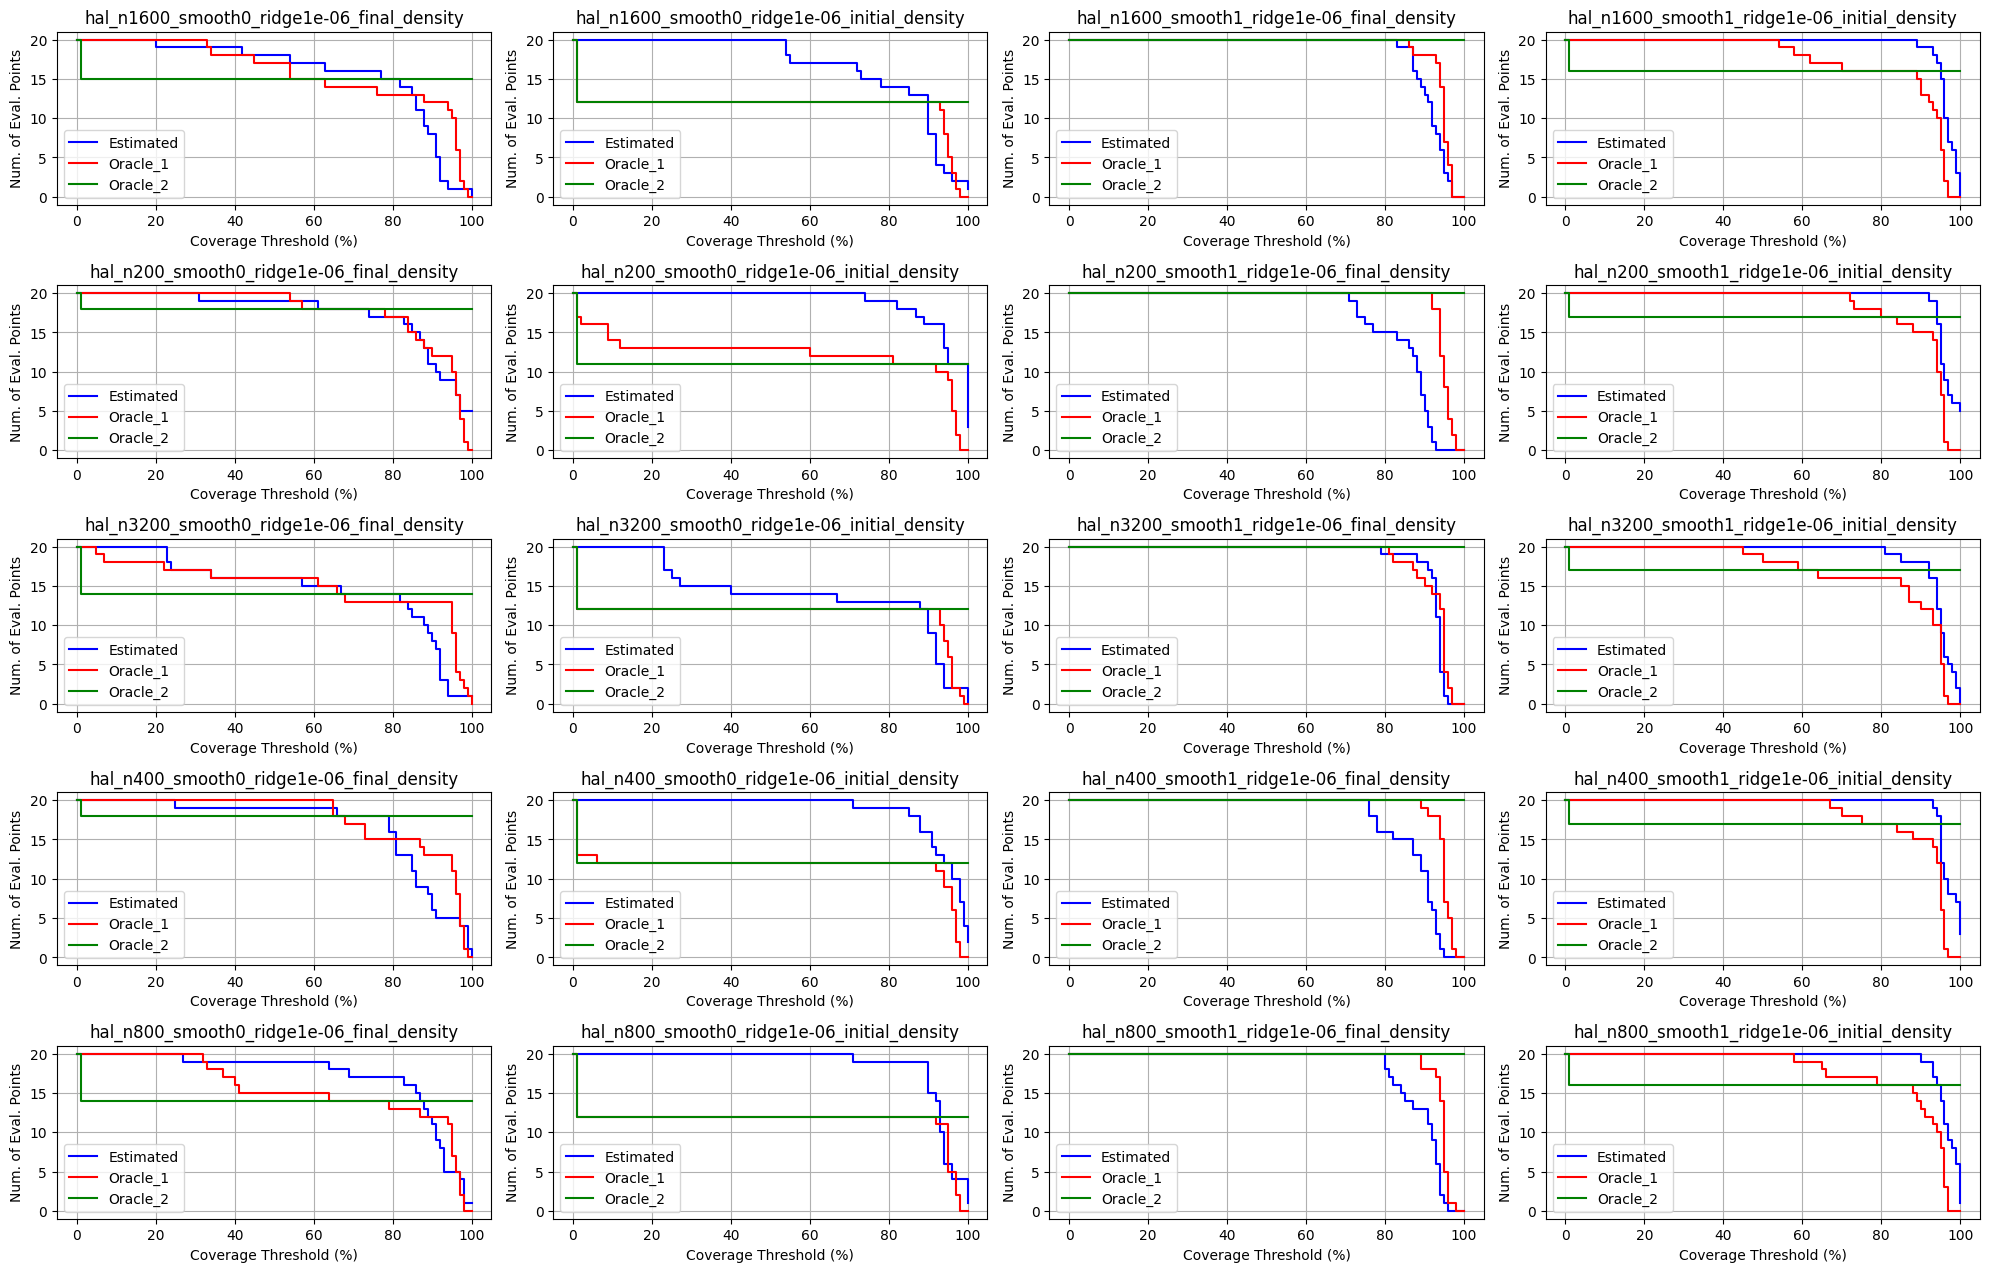

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

# -------------------------------
# Define the function to compute the true density
def compute_true_density(grid_points, mean=0.5, std=0.1, lower=0, upper=1):
    """
    Compute the true density of a truncated normal distribution over given grid points.
    """
    a, b = (lower - mean) / std, (upper - mean) / std
    return truncnorm.pdf(grid_points, a, b, loc=mean, scale=std)

# -------------------------------
# 1. Compute Estimated Coverage (using _density and _density_se files)
coverage_results = {}

for key in dataframes.keys():
    # Select files ending with '_density' (but not those ending with '_density_se')
    if key.endswith('_density') and not key.endswith('_density_se'):
        base_name = key
        se_key = base_name + '_se'  # corresponding standard error file

        if se_key in dataframes:
            density_df = dataframes[base_name]
            se_df = dataframes[se_key]

            # Assume the first column contains the evaluation (grid) points
            evaluation_points = density_df.iloc[:, 0].values
            # Compute the true density at these evaluation points
            true_density = compute_true_density(evaluation_points)

            # List to store the empirical (estimated) coverage (in %) for each evaluation point
            coverage_proportions = []
            for i in range(len(evaluation_points)):
                # For each evaluation point, extract the 200 experiments (skip first column)
                point_estimates = density_df.iloc[i, 1:].astype(float).values
                standard_errors = se_df.iloc[i, 1:].astype(float).values

                # Construct the 95% CI for each experiment using 1.96 * SE
                lower_bounds = point_estimates - 1.96 * standard_errors
                upper_bounds = point_estimates + 1.96 * standard_errors

                true_val = true_density[i]
                within_CI = (lower_bounds <= true_val) & (true_val <= upper_bounds)
                coverage = np.mean(within_CI) * 100  # percentage coverage
                coverage_proportions.append(coverage)

            # Store results in a DataFrame for later plotting
            coverage_df = pd.DataFrame({
                'Evaluation Point': evaluation_points,
                'True Density': true_density,
                'Coverage (%)': coverage_proportions
            })
            coverage_results[base_name] = coverage_df

# -------------------------------
# 2. Compute Oracle_1 Coverage (using only the _density file)
oracle_coverage_results = {}

for key in dataframes.keys():
    if key.endswith('_density') and not key.endswith('_density_se'):
        base_name = key
        density_df = dataframes[base_name]

        # Assume the first column contains the evaluation (grid) points
        evaluation_points = density_df.iloc[:, 0].values
        true_density = compute_true_density(evaluation_points)

        oracle_coverage_proportions = []
        for i in range(len(evaluation_points)):
            # Extract the 200 experiment estimates (skip first column)
            point_estimates = density_df.iloc[i, 1:].astype(float).values
            # Compute the oracle standard error as the sample standard deviation (ddof=1)
            oracle_se = np.std(point_estimates, ddof=1)
            # Construct the 95% CI for each experiment using oracle_se
            lower_bounds = point_estimates - 1.96 * oracle_se
            upper_bounds = point_estimates + 1.96 * oracle_se

            true_val = true_density[i]
            within_CI = (lower_bounds <= true_val) & (true_val <= upper_bounds)
            oracle_cov = np.mean(within_CI) * 100  # as a percentage
            oracle_coverage_proportions.append(oracle_cov)

        oracle_coverage_df = pd.DataFrame({
            'Evaluation Point': evaluation_points,
            'True Density': true_density,
            'Oracle Coverage (%)': oracle_coverage_proportions
        })
        oracle_coverage_results[base_name] = oracle_coverage_df

        # Optional: print for inspection
        print(f"Oracle_1 Coverage results for {base_name}:")
        print(oracle_coverage_df, "\n")

# -------------------------------
# 3. Compute Oracle_2 Coverage (quantile-based CI)
# For each evaluation point, we use the 200 experiment estimates to form a single quantile-based CI.
oracle_2_coverage_results = {}

for key in dataframes.keys():
    if key.endswith('_density') and not key.endswith('_density_se'):
        base_name = key
        density_df = dataframes[base_name]
        evaluation_points = density_df.iloc[:, 0].values
        true_density = compute_true_density(evaluation_points)

        oracle2_coverage_proportions = []
        for i in range(len(evaluation_points)):
            # Extract the 200 experiment estimates (skip first column)
            point_estimates = density_df.iloc[i, 1:].astype(float).values

            # Use the mean as the center (psi_n) and the sample std as sigma_n
            psi_n = np.mean(point_estimates)
            sigma_n = np.std(point_estimates, ddof=1)

            # Standardize the estimates
            z_vals = (point_estimates - psi_n) / sigma_n
            # Get the 2.5th and 97.5th percentiles of the standardized values
            q_lower = np.percentile(z_vals, 2.5)
            q_upper = np.percentile(z_vals, 97.5)
            # Construct the quantile-based CI
            lower_bound = psi_n + q_lower * sigma_n
            upper_bound = psi_n + q_upper * sigma_n

            true_val = true_density[i]
            # Here, we have one interval per evaluation point. Coverage is 100 if the true value is in the CI, else 0.
            coverage = 100 if (lower_bound <= true_val <= upper_bound) else 0
            oracle2_coverage_proportions.append(coverage)

        oracle2_df = pd.DataFrame({
            'Evaluation Point': evaluation_points,
            'True Density': true_density,
            'Oracle_2 Coverage (%)': oracle2_coverage_proportions
        })
        oracle_2_coverage_results[base_name] = oracle2_df

        # Optional: print for inspection
        print(f"Oracle_2 Coverage results for {base_name}:")
        print(oracle2_df, "\n")

# -------------------------------
# 4. Plot Survival Curves for Estimated, Oracle_1, and Oracle_2 Together
# For each file pair, we count (over evaluation points) how many have a coverage percentage
# above a grid of thresholds (from 0% to 100%).

# Get a sorted list of file pair names (base names) for which coverage was computed
file_pair_names = sorted(list(coverage_results.keys()))
n_pairs = len(file_pair_names)

# Define a fine grid of coverage thresholds from 0% to 100%
thresholds = np.linspace(0, 100, 101)

# Set up a 4x4 grid for survival plot comparisons
nrows, ncols = 8, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 20))
axes = axes.flatten()

for idx, base_name in enumerate(file_pair_names):
    ax = axes[idx]

    # Retrieve the DataFrames for this file pair.
    estimated_df = coverage_results[base_name]
    oracle1_df   = oracle_coverage_results[base_name]
    oracle2_df   = oracle_2_coverage_results[base_name]

    # Extract the coverage percentages.
    estimated_values = estimated_df['Coverage (%)'].values
    oracle1_values   = oracle1_df['Oracle Coverage (%)'].values
    oracle2_values   = oracle2_df['Oracle_2 Coverage (%)'].values

    # For each threshold, count how many evaluation points have coverage >= threshold.
    estimated_survival = [np.sum(estimated_values >= thr) for thr in thresholds]
    oracle1_survival   = [np.sum(oracle1_values   >= thr) for thr in thresholds]
    oracle2_survival   = [np.sum(oracle2_values   >= thr) for thr in thresholds]

    # Plot the survival curves using step plots
    ax.step(thresholds, estimated_survival, where='post', label='Estimated', color='blue')
    ax.step(thresholds, oracle1_survival,   where='post', label='Oracle_1', color='red')
    ax.step(thresholds, oracle2_survival,   where='post', label='Oracle_2', color='green')

    ax.set_title(base_name)
    ax.set_xlabel('Coverage Threshold (%)')
    ax.set_ylabel('Num. of Eval. Points')
    ax.legend()
    ax.grid(True)

# Remove extra subplots if there are fewer than 16 file pairs
for j in range(idx + 1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


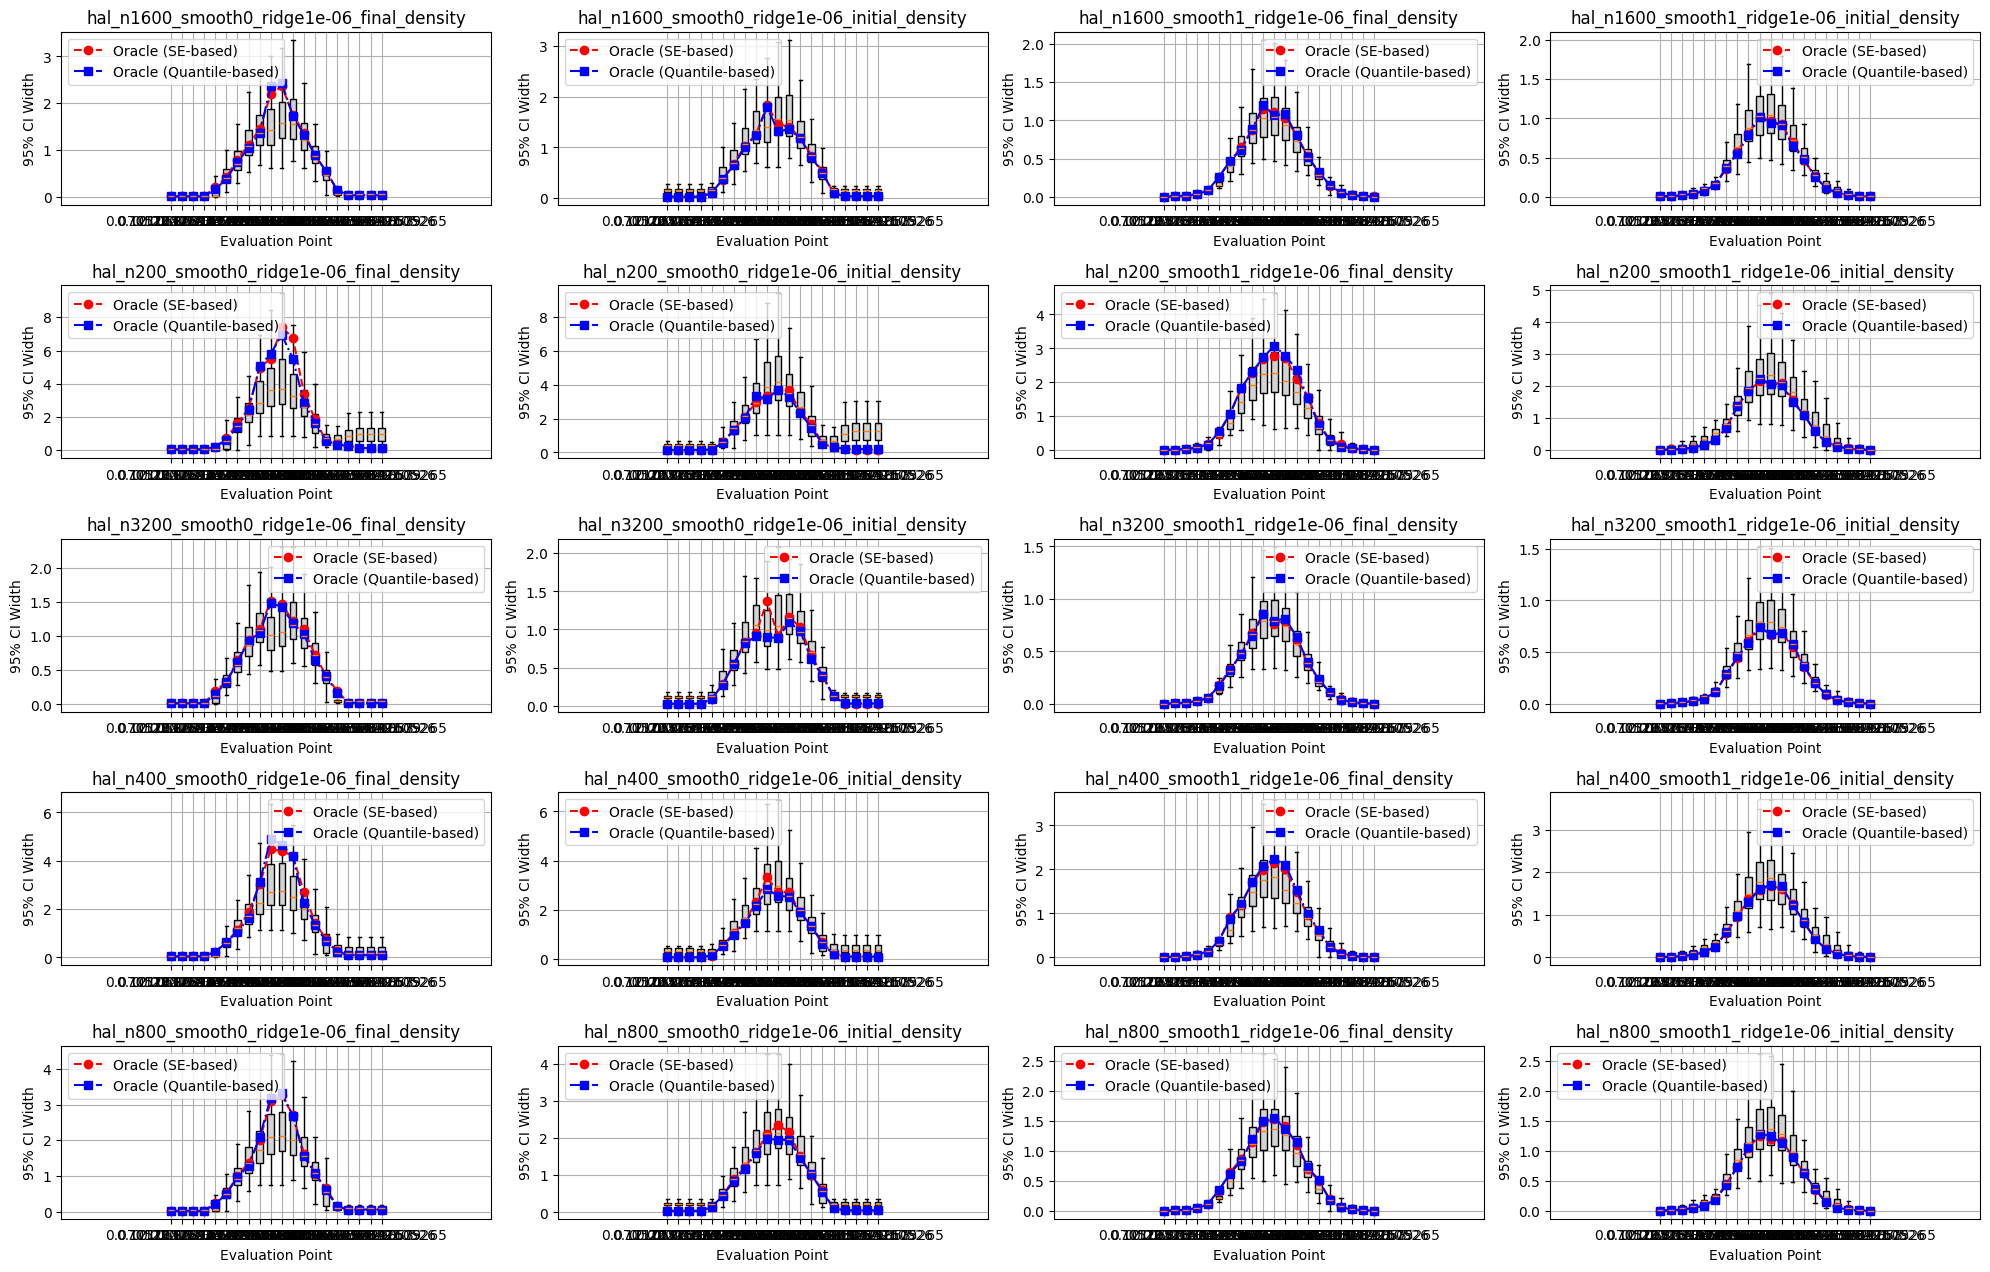

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# We'll collect the CI width data and the two oracle estimates for each file pair.
ci_width_results = {}

for key in dataframes.keys():
    # Look for keys that end with '_density' (but not '_density_se')
    if key.endswith('_density') and not key.endswith('_density_se'):
        base_name = key
        se_key = base_name + '_se'
        if se_key in dataframes:
            density_df = dataframes[base_name]
            se_df = dataframes[se_key]

            # Assume the first column holds the evaluation (grid) points
            eval_points = density_df.iloc[:, 0].values

            # Prepare lists to store data for each evaluation point
            boxplot_data = []      # List of arrays: one array per evaluation point (CI widths across experiments)
            oracle_widths1 = []    # Oracle CI widths based on the sample standard deviation (SE-based)
            oracle_widths2 = []    # Oracle CI widths based on the quantile-based method

            # Loop over evaluation points (each row)
            for i in range(len(eval_points)):
                # -- From the _density_se file: Compute CI widths for each experiment
                se_values = se_df.iloc[i, 1:].astype(float).values
                ci_widths = 2 * 1.96 * se_values
                boxplot_data.append(ci_widths)

                # -- From the _density file: Get the point estimates for this evaluation point
                point_estimates = density_df.iloc[i, 1:].astype(float).values

                # Oracle Method 1: SE-based oracle
                oracle_se = np.std(point_estimates, ddof=1)
                oracle_ci_width1 = 2 * 1.96 * oracle_se
                oracle_widths1.append(oracle_ci_width1)

                # Oracle Method 2: Quantile-based oracle
                # First, compute the mean and std (psi_n and sigma_n)
                psi_n = np.mean(point_estimates)
                sigma_n = np.std(point_estimates, ddof=1)
                # Standardize the estimates
                z_vals = (point_estimates - psi_n) / sigma_n
                # Get the 2.5th and 97.5th percentiles of the standardized values
                q_lower = np.percentile(z_vals, 2.5)
                q_upper = np.percentile(z_vals, 97.5)
                # The CI width is sigma_n times the difference in quantiles
                oracle_ci_width2 = sigma_n * (q_upper - q_lower)
                oracle_widths2.append(oracle_ci_width2)

            # Save the computed results for this file pair.
            ci_width_results[base_name] = {
                'eval_points': eval_points,
                'boxplot_data': boxplot_data,
                'oracle_widths1': oracle_widths1,
                'oracle_widths2': oracle_widths2
            }

# ---
# Now plot the results in a 4x4 grid.
file_names = sorted(ci_width_results.keys())
n_files = len(file_names)
nrows, ncols = 8, 4

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 20))
axes = axes.flatten()

for idx, base_name in enumerate(file_names):
    ax = axes[idx]
    res = ci_width_results[base_name]
    eval_points = res['eval_points']
    box_data = res['boxplot_data']
    oracle1 = res['oracle_widths1']
    oracle2 = res['oracle_widths2']

    # Create the boxplot.
    # We'll use the evaluation points as the positions.
    bp = ax.boxplot(box_data, positions=eval_points, widths=0.03, patch_artist=True, showfliers=False)

    # Customize the boxplot (optional)
    for box in bp['boxes']:
        box.set(facecolor='lightgray')

    ax.set_title(base_name)
    ax.set_xlabel("Evaluation Point")
    ax.set_ylabel("95% CI Width")

    # Overlay the oracle estimates as lines.
    ax.plot(eval_points, oracle1, color='red', linestyle='--', marker='o', label='Oracle (SE-based)')
    ax.plot(eval_points, oracle2, color='blue', linestyle='-.', marker='s', label='Oracle (Quantile-based)')
    ax.legend()
    ax.grid(True)

# Remove any extra subplots if there are fewer than 16 file pairs.
for j in range(idx + 1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


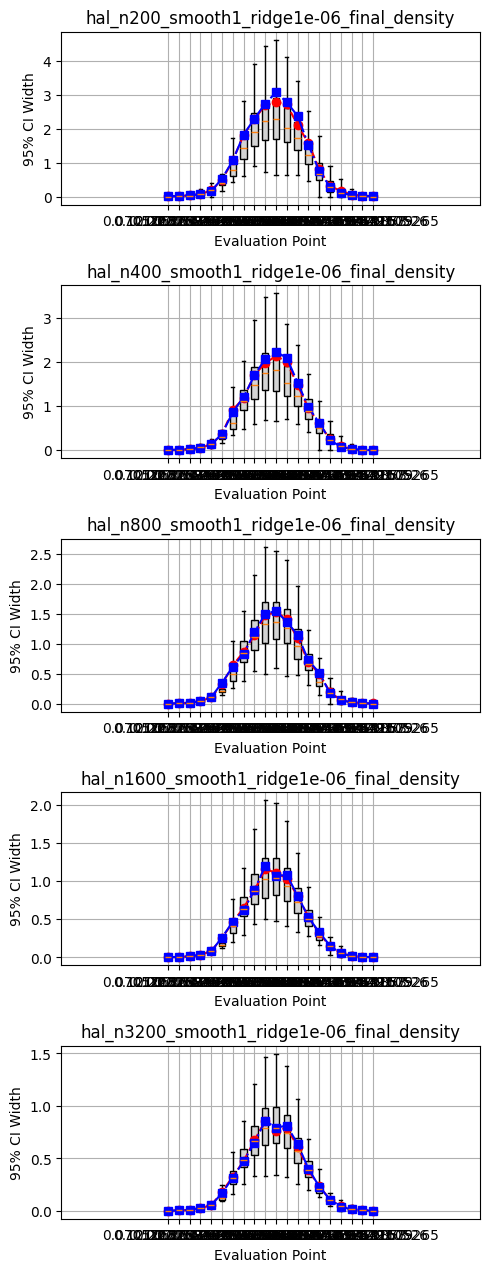

In [4]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Filter for keys that correspond to smooth order 1 and final survival results.
ci_width_results = {}

for key in dataframes.keys():
    # We only want keys that end with '_survival' (and not '_survival_se') and contain 'smooth1'
    if key.endswith('final_density') and not key.endswith('_density_se') and "smooth1" in key:
        base_name = key
        se_key = base_name + '_se'
        if se_key in dataframes:
            survival_df = dataframes[base_name]
            se_df = dataframes[se_key]

            # Assume the first column holds the evaluation (grid) points.
            eval_points = survival_df.iloc[:, 0].values

            boxplot_data = []      # List of arrays: one array per evaluation point (CI widths across experiments)
            oracle_widths1 = []    # Oracle CI widths based on the sample standard deviation (SE-based)
            oracle_widths2 = []    # Oracle CI widths based on the quantile-based method

            for i in range(len(eval_points)):
                se_values = se_df.iloc[i, 1:].astype(float).values
                ci_widths = 2 * 1.96 * se_values
                boxplot_data.append(ci_widths)

                point_estimates = survival_df.iloc[i, 1:].astype(float).values

                oracle_se = np.std(point_estimates, ddof=1)
                oracle_ci_width1 = 2 * 1.96 * oracle_se
                oracle_widths1.append(oracle_ci_width1)

                psi_n = np.mean(point_estimates)
                sigma_n = np.std(point_estimates, ddof=1)
                z_vals = (point_estimates - psi_n) / sigma_n
                q_lower = np.percentile(z_vals, 2.5)
                q_upper = np.percentile(z_vals, 97.5)
                oracle_ci_width2 = sigma_n * (q_upper - q_lower)
                oracle_widths2.append(oracle_ci_width2)

            ci_width_results[base_name] = {
                'eval_points': eval_points,
                'boxplot_data': boxplot_data,
                'oracle_widths1': oracle_widths1,
                'oracle_widths2': oracle_widths2
            }

# Define a helper function to extract sample size from the key.
def extract_sample_size(key):
    match = re.search(r"hal_n(\d+)_", key)
    if match:
        return int(match.group(1))
    else:
        return float('inf')

# Filter keys that are in smooth order 1 and sort them by sample size.
file_names = [k for k in ci_width_results.keys() if "smooth1" in k]
file_names = sorted(file_names, key=extract_sample_size)

# Plot the results in an 8x4 grid.
n_files = len(file_names)
nrows, ncols = 8, 1
fig, axes = plt.subplots(nrows, ncols, figsize=(5, 20))
axes = axes.flatten()

for idx, base_name in enumerate(file_names):
    ax = axes[idx]
    res = ci_width_results[base_name]
    eval_points = res['eval_points']
    box_data = res['boxplot_data']
    oracle1 = res['oracle_widths1']
    oracle2 = res['oracle_widths2']

    bp = ax.boxplot(box_data, positions=eval_points, widths=0.03, patch_artist=True, showfliers=False)
    for box in bp['boxes']:
        box.set(facecolor='lightgray')

    ax.set_title(base_name)
    ax.set_xlabel("Evaluation Point")
    ax.set_ylabel("95% CI Width")
    ax.plot(eval_points, oracle1, color='red', linestyle='--', marker='o', label='Oracle (SE-based)')
    ax.plot(eval_points, oracle2, color='blue', linestyle='-.', marker='s', label='Oracle (Quantile-based)')
    #ax.legend()
    ax.grid(True)

for j in range(idx + 1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Reading file: hal_n200_smooth1_ridge1e-06_final_density.csv
Reading file: hal_n400_smooth1_ridge1e-06_final_density.csv
Reading file: hal_n1600_smooth1_ridge1e-06_final_density.csv
Reading file: hal_n800_smooth1_ridge1e-06_final_density.csv
Reading file: hal_n3200_smooth0_ridge1e-06_final_density.csv
Reading file: hal_n3200_smooth1_ridge1e-06_final_density.csv
Reading file: hal_n800_smooth0_ridge1e-06_final_density.csv
Reading file: hal_n1600_smooth0_ridge1e-06_final_density.csv
Reading file: hal_n400_smooth0_ridge1e-06_final_density.csv
Reading file: hal_n200_smooth0_ridge1e-06_final_density.csv


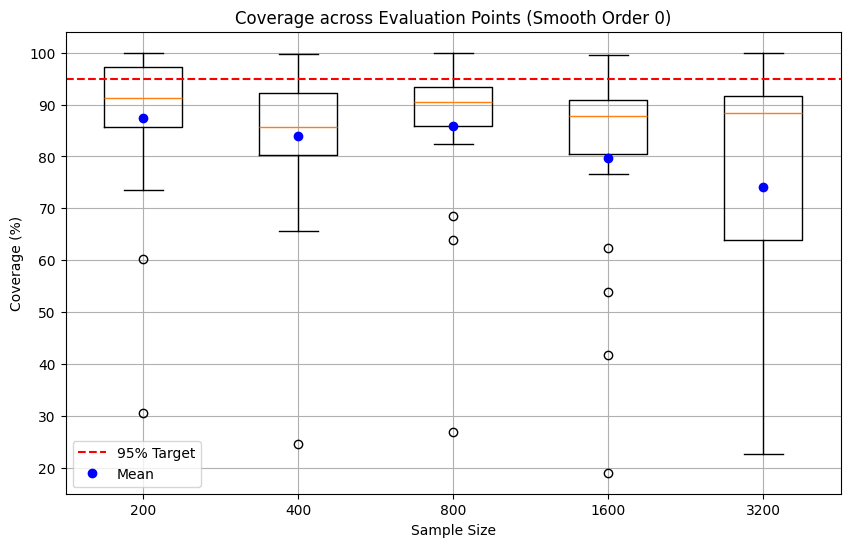

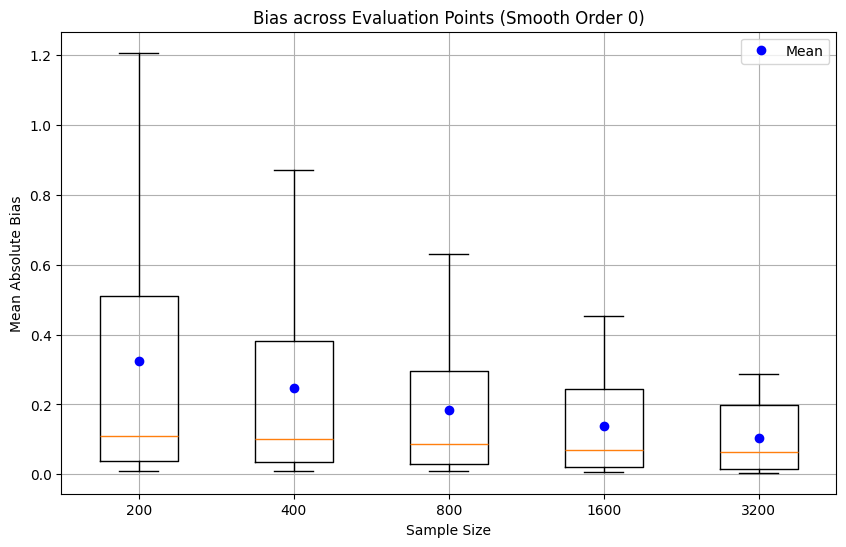

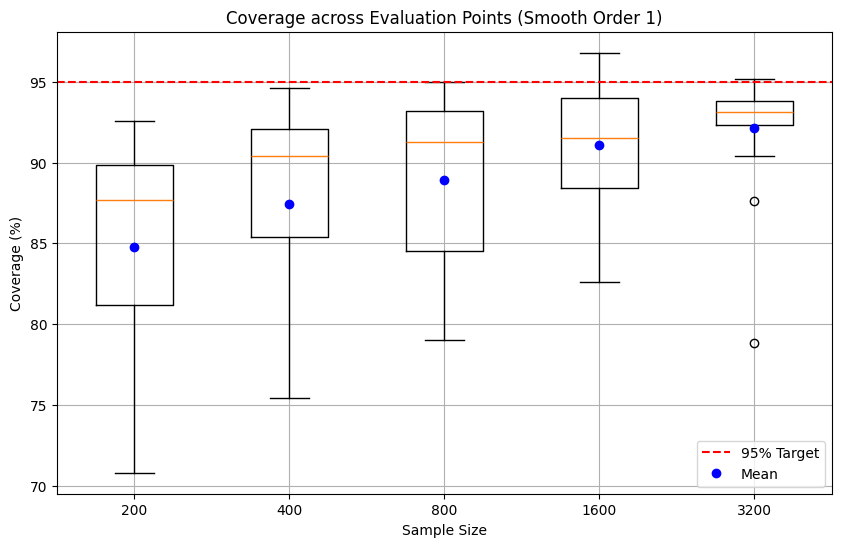

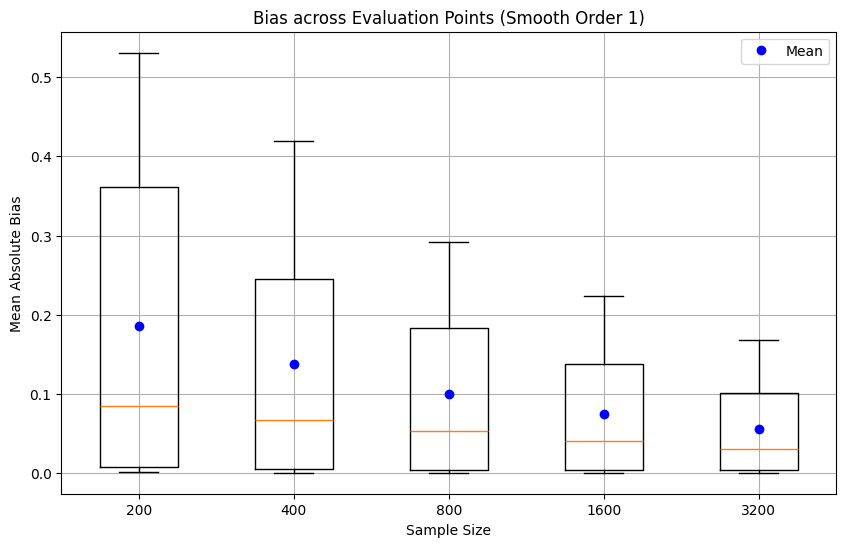

In [5]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import truncnorm


# Define a function to compute the true density (truncated normal)
def compute_true_density(grid_points, mean=0.5, std=0.1, lower=0, upper=1):
    a, b = (lower - mean) / std, (upper - mean) / std
    return truncnorm.pdf(grid_points, a, b, loc=mean, scale=std)

# Use a regex that extracts both sample size and smooth order.
# For example, file names like "hal_n800_smooth0_..." or "hal_n800_smooth1_..."
density_files = glob.glob(os.path.join(folder_path, "*final_density.csv"))

# Dictionaries to store aggregated pointwise coverage and bias.
# Key: (n_samples, smooth_order)
coverage_data = {}
bias_data = {}

# Loop over each density file
for density_file in density_files:
    basename = os.path.basename(density_file)
    print("Reading file:", basename)
    # Adjust regex to capture sample size and smooth order.
    match = re.search(r"hal_n(\d+)_smooth(\d+)_", basename)
    if not match:
        print("No sample size or smooth order found in:", basename)
        continue
    n_samples = int(match.group(1))
    smooth_order = int(match.group(2))
    key = (n_samples, smooth_order)
    
    # Determine the corresponding standard error file name.
    se_file = density_file.replace("final_density.csv", "final_density_se.csv")
    if not os.path.exists(se_file):
        print(f"SE file not found for {density_file}")
        continue

    # Read CSV files
    density_df = pd.read_csv(density_file)
    se_df = pd.read_csv(se_file)
    
    # Assume first column is the evaluation grid.
    eval_points = density_df.iloc[:, 0].values
    true_density = compute_true_density(eval_points)
    
    # Compute pointwise coverage and bias for each evaluation point.
    coverage_per_eval = []
    bias_per_eval = []
    for i in range(len(eval_points)):
        est_values = density_df.iloc[i, 1:].astype(float).values
        se_values  = se_df.iloc[i, 1:].astype(float).values
        
        # Construct the 95% confidence intervals.
        lower_bounds = est_values - 1.96 * se_values
        upper_bounds = est_values + 1.96 * se_values
        
        # Coverage: percentage of experiments whose CI contains the true density.
        cov_percentage = np.mean((true_density[i] >= lower_bounds) & (true_density[i] <= upper_bounds)) * 100
        coverage_per_eval.append(cov_percentage)
        
        # Bias: mean absolute difference at this evaluation point.
        bias_val = np.mean(np.abs(est_values - true_density[i]))
        bias_per_eval.append(bias_val)
    
    # Aggregate results by (n_samples, smooth_order)
    if key in coverage_data:
        coverage_data[key].extend(coverage_per_eval)
        bias_data[key].extend(bias_per_eval)
    else:
        coverage_data[key] = coverage_per_eval
        bias_data[key] = bias_per_eval

# Now, we want to produce separate graphs for each smooth order.
smooth_orders = sorted(set(s for (_, s) in coverage_data.keys()))

for smooth in smooth_orders:
    # For the current smooth order, extract sample sizes and corresponding groups.
    sample_sizes = sorted(n for (n, s) in coverage_data.keys() if s == smooth)
    # Build lists for the boxplot data.
    coverage_boxplot_data = [coverage_data[(n, smooth)] for n in sample_sizes]
    bias_boxplot_data = [bias_data[(n, smooth)] for n in sample_sizes]
    
    # Plot Coverage for this smooth order.
    plt.figure(figsize=(10, 6))
    plt.boxplot(coverage_boxplot_data)
    plt.axhline(y=95, color='red', linestyle='--', label='95% Target')
    means_coverage = [np.mean(group) for group in coverage_boxplot_data]
    plt.plot(range(1, len(means_coverage) + 1), means_coverage, marker='o', color='blue', linestyle='None', label='Mean')
    plt.xticks(ticks=range(1, len(sample_sizes) + 1), labels=[str(s) for s in sample_sizes])
    plt.xlabel("Sample Size")
    plt.ylabel("Coverage (%)")
    plt.title(f"Coverage across Evaluation Points (Smooth Order {smooth})")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Plot Bias for this smooth order.
    plt.figure(figsize=(10, 6))
    plt.boxplot(bias_boxplot_data)
    means_bias = [np.mean(group) for group in bias_boxplot_data]
    plt.plot(range(1, len(means_bias) + 1), means_bias, marker='o', color='blue', linestyle='None', label='Mean')
    plt.xticks(ticks=range(1, len(sample_sizes) + 1), labels=[str(s) for s in sample_sizes])
    plt.xlabel("Sample Size")
    plt.ylabel("Mean Absolute Bias")
    plt.title(f"Bias across Evaluation Points (Smooth Order {smooth})")
    plt.legend()
    plt.grid(True)
    plt.show()


Processing: hal_n200_smooth1_ridge1e-06_final_density.csv
Processing: hal_n400_smooth1_ridge1e-06_final_density.csv
Processing: hal_n1600_smooth1_ridge1e-06_final_density.csv
Processing: hal_n800_smooth1_ridge1e-06_final_density.csv
Processing: hal_n3200_smooth0_ridge1e-06_final_density.csv
Processing: hal_n3200_smooth1_ridge1e-06_final_density.csv
Processing: hal_n800_smooth0_ridge1e-06_final_density.csv
Processing: hal_n1600_smooth0_ridge1e-06_final_density.csv
Processing: hal_n400_smooth0_ridge1e-06_final_density.csv
Processing: hal_n200_smooth0_ridge1e-06_final_density.csv


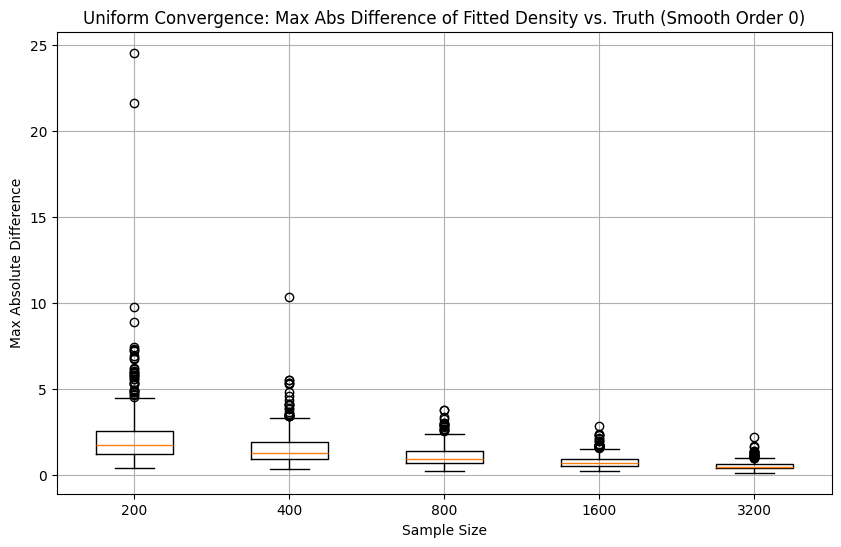

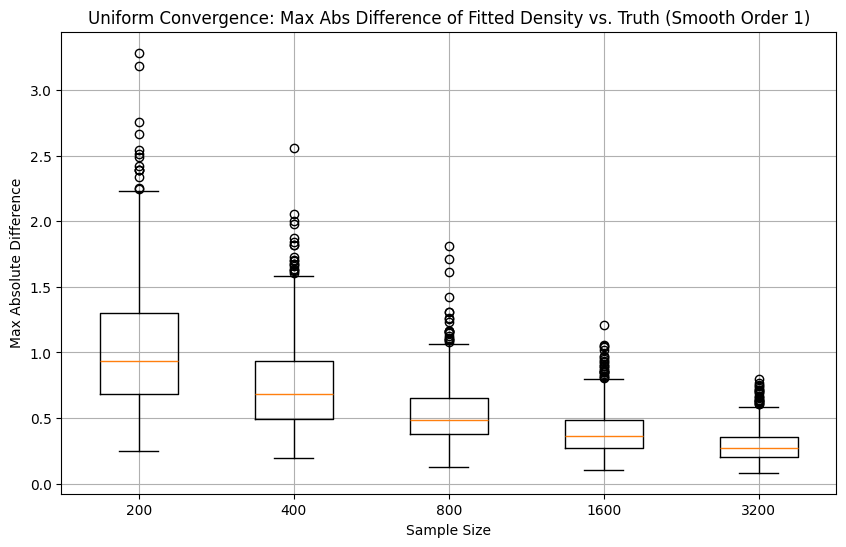

In [6]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

# Define a function to compute the true density (truncated normal)
def compute_true_density(grid_points, mean=0.5, std=0.1, lower=0, upper=1):
    a, b = (lower - mean) / std, (upper - mean) / std
    return truncnorm.pdf(grid_points, a, b, loc=mean, scale=std)



# Get all final density CSV files (adjust the pattern if needed)
density_files = glob.glob(os.path.join(folder_path, "*final_density.csv"))

# Dictionary to store the uniform convergence metric for each (sample size, smooth order).
# For each key, we store a list of maximum absolute differences (one per simulation replicate).
uniform_diff_data = {}

# Loop over each density file
for density_file in density_files:
    basename = os.path.basename(density_file)
    print("Processing:", basename)
    # Extract both sample size and smooth order from the file name.
    # Example filename: "hal_n800_smooth0_final_density.csv"
    match = re.search(r"hal_n(\d+)_smooth(\d+)_", basename)
    if not match:
        print("No sample size or smooth order found in:", basename)
        continue
    n_samples = int(match.group(1))
    smooth_order = int(match.group(2))
    key = (n_samples, smooth_order)
    
    # Read the CSV file into a DataFrame
    density_df = pd.read_csv(density_file)
    
    # Assume the first column is the evaluation grid and the rest are simulation experiments.
    eval_points = density_df.iloc[:, 0].values
    true_density = compute_true_density(eval_points)
    
    # For each simulation replicate (each column after the first),
    # calculate the maximum absolute difference between the fitted value and the truth.
    max_diffs = []
    for col in density_df.columns[1:]:
        # Convert the experiment's estimated density to float
        est_values = density_df[col].astype(float).values
        # Compute absolute differences at each evaluation point
        abs_diff = np.abs(est_values - true_density)
        # The uniform error is the maximum absolute difference over the grid
        max_diff = np.max(abs_diff)
        max_diffs.append(max_diff)
    
    # Aggregate the maximum differences by (n_samples, smooth_order)
    if key in uniform_diff_data:
        uniform_diff_data[key].extend(max_diffs)
    else:
        uniform_diff_data[key] = max_diffs

# Now, group the results by smooth order.
smooth_orders = sorted(set(s for (n, s) in uniform_diff_data.keys()))
for smooth in smooth_orders:
    # For the current smooth order, extract the sample sizes and corresponding data.
    sample_sizes = sorted(n for (n, s) in uniform_diff_data.keys() if s == smooth)
    boxplot_data = [uniform_diff_data[(n, smooth)] for n in sample_sizes]
    
    # Plot the box plot for uniform convergence for this smooth order.
    plt.figure(figsize=(10, 6))
    plt.boxplot(boxplot_data)
    plt.xticks(ticks=range(1, len(sample_sizes) + 1), labels=[str(n) for n in sample_sizes])
    plt.xlabel("Sample Size")
    plt.ylabel("Max Absolute Difference")
    plt.title(f"Uniform Convergence: Max Abs Difference of Fitted Density vs. Truth (Smooth Order {smooth})")
    plt.grid(True)
    plt.show()


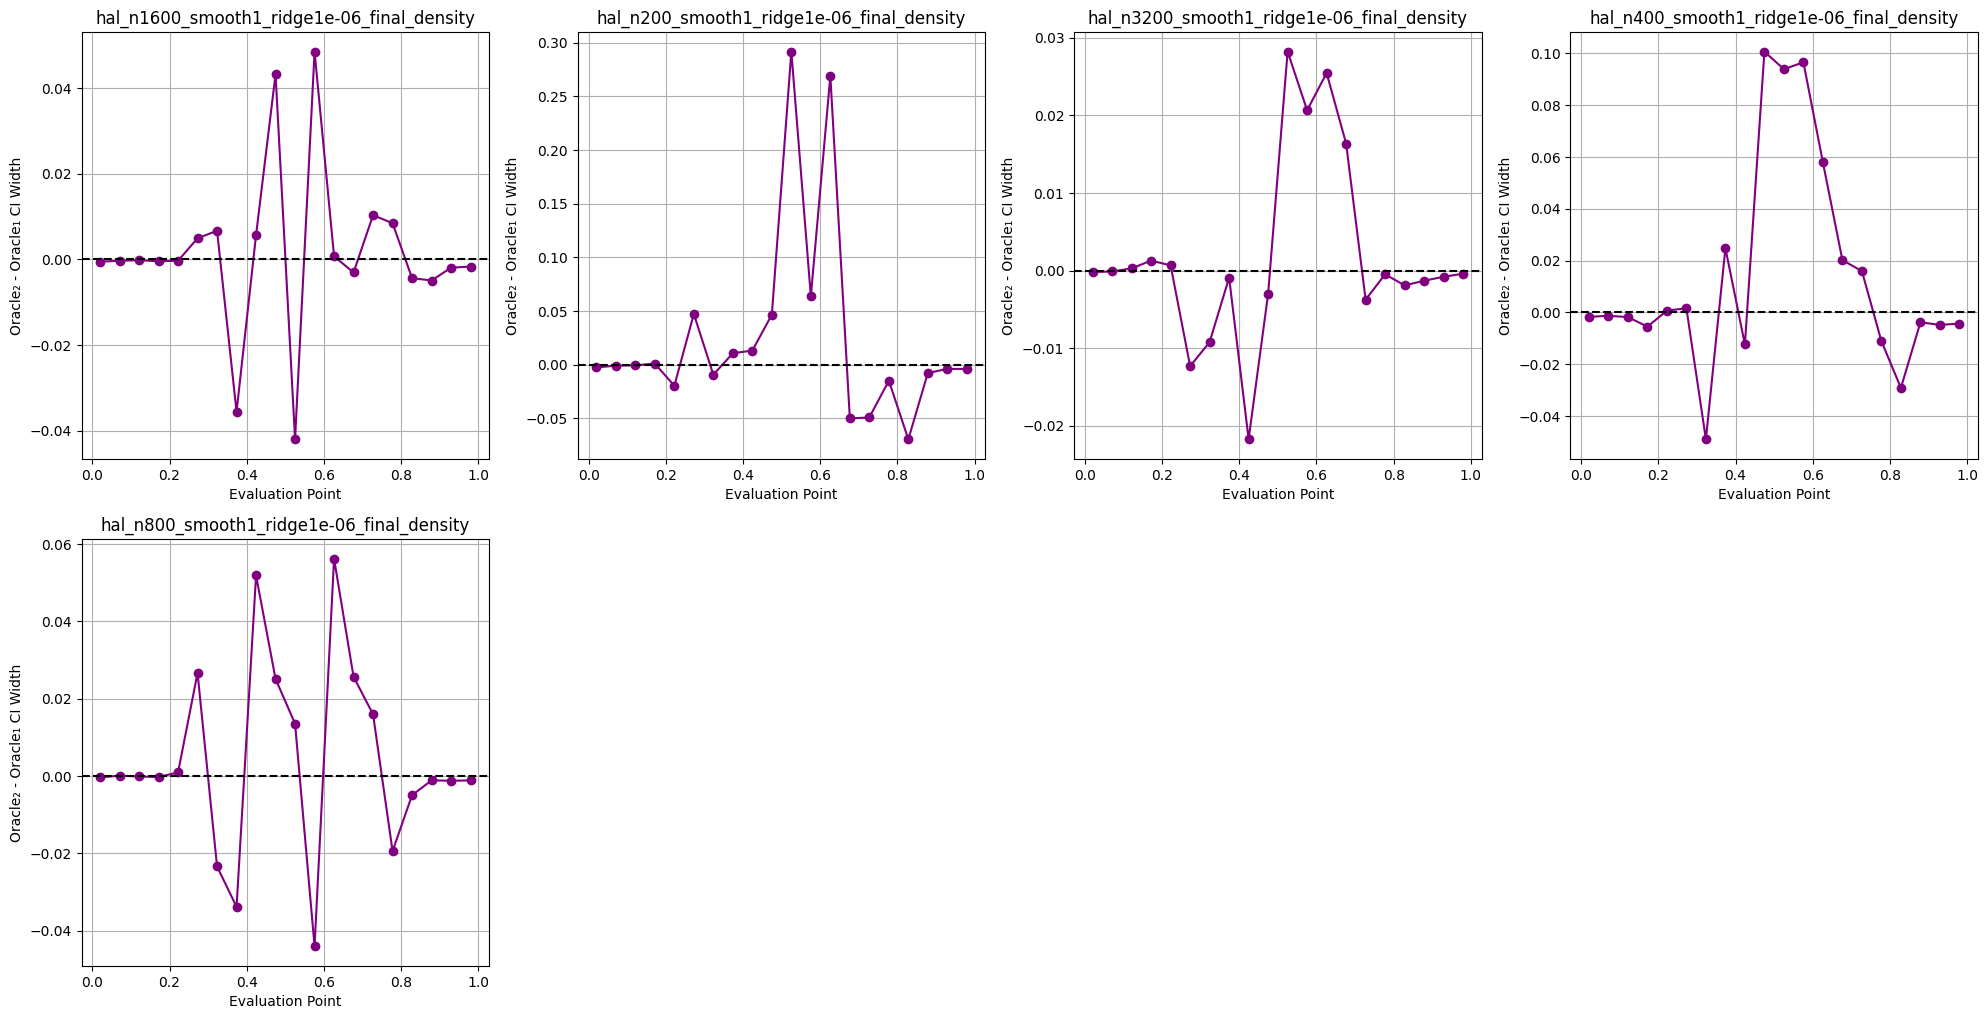

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Plot the difference between Oracle_2 and Oracle_1 CI widths for each file pair
file_names = sorted(ci_width_results.keys())
n_files = len(file_names)
nrows, ncols = 4, 4

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 20))
axes = axes.flatten()

for idx, base_name in enumerate(file_names):
    ax = axes[idx]
    res = ci_width_results[base_name]
    eval_points = res['eval_points']

    # Compute difference: Oracle_2 - Oracle_1
    oracle_diff = np.array(res['oracle_widths2']) - np.array(res['oracle_widths1'])

    # Plot the difference across evaluation points
    ax.plot(eval_points, oracle_diff, marker='o', linestyle='-', color='purple')
    ax.axhline(y=0, color='black', linestyle='--')
    ax.set_title(base_name)
    ax.set_xlabel("Evaluation Point")
    ax.set_ylabel("Oracle₂ - Oracle₁ CI Width")
    ax.grid(True)

# Remove any extra subplots if there are fewer than 16 file pairs.
for j in range(idx + 1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Below is one strategy: we can compute a composite score for each file that rewards high IQR coverage proportions and penalizes a high Wasserstein distance. For example, if our summary table for each file contains:

- **Wasserstein Dist.** (we want this to be low)
- **Oracle1 IQR Coverage (prop.)** (we want this to be high; it’s a proportion between 0 and 1)

One simple composite score is given by:

$$
\text{Composite Score} = 50 \times \left(\text{Oracle1 IQR Coverage (prop.)}\right) + 50 \times \left(\text{Oracle2 IQR Coverage (prop.)}\right) - \left(\text{Wasserstein Dist.}\right)
$$

Multiplying the coverage proportion by 100 puts it roughly on the same scale as the Wasserstein distance (which is in percentage points). Then, by sorting in descending order, the files with the highest composite score will be those that have both high coverage and low Wasserstein distance.

Here’s an example code snippet to do this for your density CI estimation summary.


In [8]:
from scipy.stats import wasserstein_distance

# Prepare lists to collect summary metrics for each file
summary_data = []

# We assume that the three dictionaries (coverage_results, oracle_coverage_results, ci_width_results)
# have the same keys (base names) for our 16 cases.
for base_name in sorted(coverage_results.keys()):
    # -- 1. Wasserstein Distance between estimated and oracle coverage distributions --
    # Get the estimated coverage: 20 values (one per evaluation point)
    est_coverage = np.array(coverage_results[base_name]['Coverage (%)'])
    # Get the oracle coverage: 20 values (from oracle coverage results; here we use the one we computed earlier)
    oracle_coverage = np.array(oracle_coverage_results[base_name]['Oracle Coverage (%)'])
    # Compute the one-dimensional Wasserstein distance between the two sets
    W_distance = wasserstein_distance(est_coverage, oracle_coverage)

    # -- 2. IQR Coverage of the Boxplots --
    # For each evaluation point, check whether the oracle CI width is within the IQR of the boxplot data.
    box_data = ci_width_results[base_name]['boxplot_data']   # list of arrays, length 20
    oracle_widths1 = ci_width_results[base_name]['oracle_widths1']  # list of 20 values (oracle 1)
    oracle_widths2 = ci_width_results[base_name]['oracle_widths2']  # list of 20 values (oracle 2)

    count_in_IQR_oracle1 = 0
    count_in_IQR_oracle2 = 0
    n_eval = len(box_data)  # typically 20 evaluation points

    for i in range(n_eval):
        # Compute the IQR (25th and 75th percentiles) for the CI widths at evaluation point i
        lower_q, upper_q = np.percentile(box_data[i], [25, 75])
        # Check if the oracle CI width (oracle 1) is within this IQR
        if lower_q <= oracle_widths1[i] <= upper_q:
            count_in_IQR_oracle1 += 1
        # Check for oracle 2
        if lower_q <= oracle_widths2[i] <= upper_q:
            count_in_IQR_oracle2 += 1

    # Convert counts to proportions (or keep counts out of 20)
    prop_oracle1 = count_in_IQR_oracle1 / n_eval
    prop_oracle2 = count_in_IQR_oracle2 / n_eval

    # Append the results to our summary list
    summary_data.append({
        'File': base_name,
        'Wasserstein Dist.': W_distance,
        'Oracle1 IQR Coverage (prop.)': prop_oracle1,
        'Oracle2 IQR Coverage (prop.)': prop_oracle2
    })

# Create a summary DataFrame and display it
summary_df = pd.DataFrame(summary_data)
print(summary_df)


KeyError: 'hal_n1600_smooth0_ridge1e-06_final_density'

In [9]:
# Assume summary_df contains the following columns:
# 'File', 'Wasserstein Dist.', 'Oracle1 IQR Coverage (prop.)'
# We'll compute the composite score if it hasn't been computed yet:
summary_df['Composite Score'] = 50 * summary_df['Oracle1 IQR Coverage (prop.)'] + 50 * summary_df['Oracle2 IQR Coverage (prop.)'] - summary_df['Wasserstein Dist.']

# Create a new column 'Smooth' based on the file name,
# assuming that the file name contains either 'smooth1' or 'smooth0'
summary_df['Smooth'] = summary_df['File'].apply(lambda x: 'smooth1' if 'smooth1' in x else 'smooth0')

# Group by the 'Smooth' column and select the top two files by composite score for each group.
best_smooth1 = summary_df[summary_df['Smooth'] == 'smooth1'].sort_values('Composite Score', ascending=False).head(2)
best_smooth0 = summary_df[summary_df['Smooth'] == 'smooth0'].sort_values('Composite Score', ascending=False).head(2)

print("Top two files in smooth1:")
print(best_smooth1)
print("\nTop two files in smooth0:")
print(best_smooth0)

NameError: name 'summary_df' is not defined

IndexError: index 16 is out of bounds for axis 0 with size 16

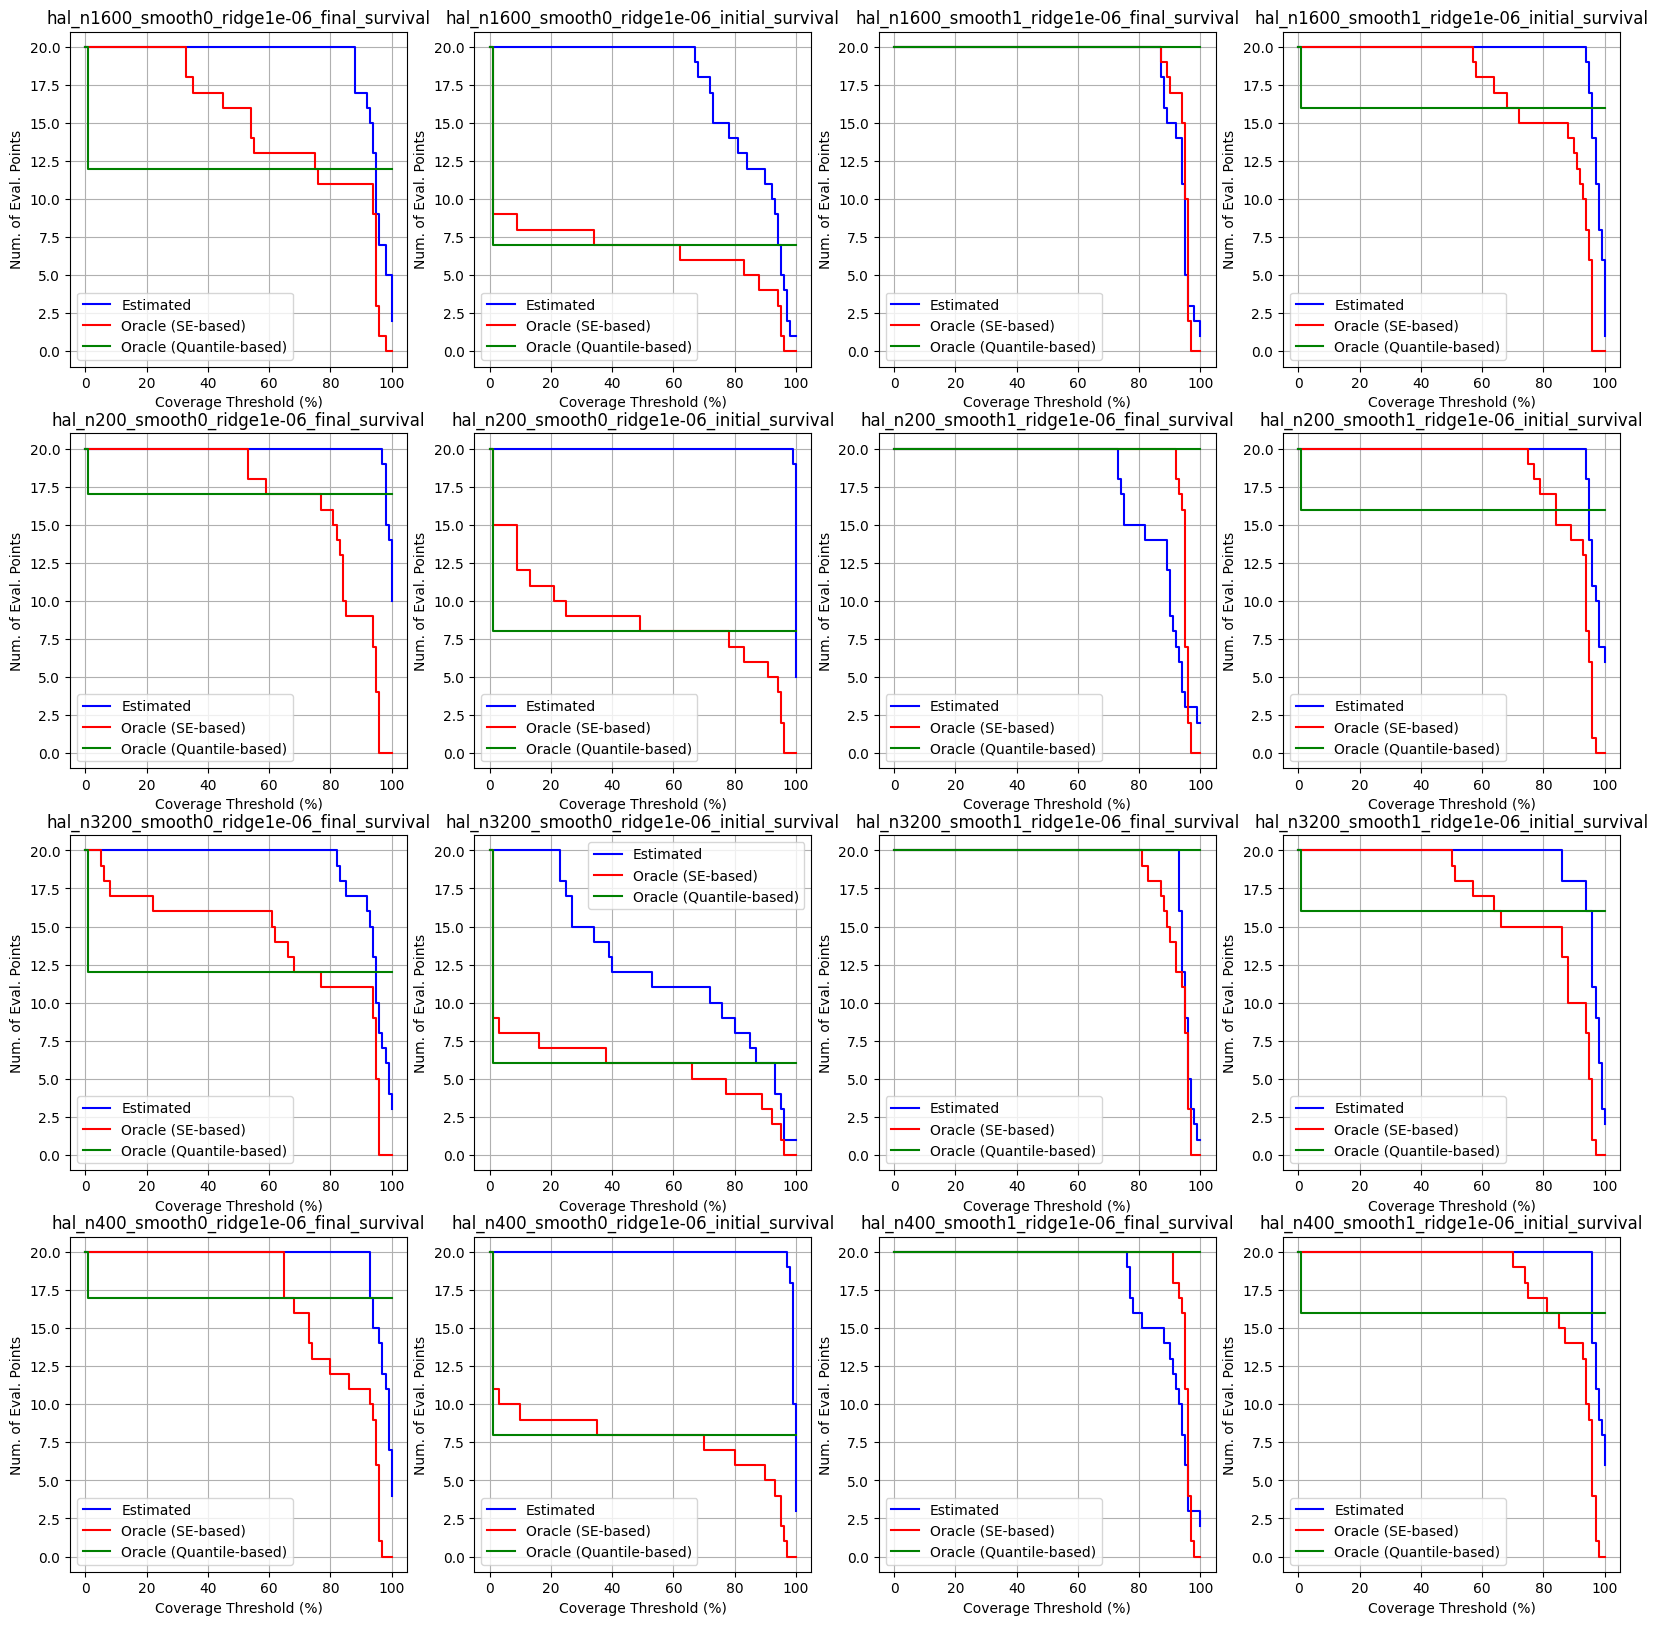

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import truncnorm, wasserstein_distance

#----------------------------------------------------------------------------
# 1. Define a function to compute the "true" survival function.
#    (Here we assume the survival is computed from the same truncated normal
#     distribution as before, but using the survival function.)
def compute_true_survival(grid_points, mean=0.5, std=0.1, lower=0, upper=1):
    a, b = (lower - mean) / std, (upper - mean) / std
    return truncnorm.sf(grid_points, a, b, loc=mean, scale=std)

#----------------------------------------------------------------------------
# 2. Process all _survival files to compute:
#    - Estimated coverage (from _survival_se)
#    - Oracle coverage (using oracle SE from _survival) [Oracle_1]
#    - Oracle_2 coverage (using the quantile-based method)
#    - CI width data and two oracle CI widths (for boxplots)
coverage_results_survival = {}
oracle_coverage_results_survival = {}
ci_width_results_survival = {}

for key in dataframes.keys():
    if key.endswith('_survival') and not key.endswith('_survival_se'):
        base_name = key
        se_key = base_name + '_se'
        if se_key in dataframes:
            # Load the survival and survival_se DataFrames
            survival_df    = dataframes[base_name]
            survival_se_df = dataframes[se_key]

            # Assume the first column contains evaluation points (e.g., time or other index)
            eval_points = survival_df.iloc[:, 0].values
            true_survival = compute_true_survival(eval_points)

            # Containers for coverage and CI-width computations
            est_coverage_list = []
            oracle_coverage_list = []   # Oracle_1 (SE-based)
            oracle2_coverage_list = []  # Oracle_2 (quantile-based)
            boxplot_data = []           # List (length = number of eval points) of arrays (each of length 200)
            oracle_widths1 = []         # Oracle CI widths based on sample SE (Oracle_1)
            oracle_widths2 = []         # Oracle CI widths based on quantile-based method (Oracle_2)

            for i in range(len(eval_points)):
                # --- Coverage computations ---
                # Extract the 200 experiments (skip the first column)
                point_estimates = survival_df.iloc[i, 1:].astype(float).values
                se_values       = survival_se_df.iloc[i, 1:].astype(float).values

                # Estimated 95% CI for each experiment (using provided SE)
                lower_bounds = point_estimates - 1.96 * se_values
                upper_bounds = point_estimates + 1.96 * se_values
                true_val = true_survival[i]
                within_CI = (lower_bounds <= true_val) & (true_val <= upper_bounds)
                coverage_val = np.mean(within_CI) * 100
                est_coverage_list.append(coverage_val)

                # Oracle_1 coverage: compute oracle SE from the 200 point estimates
                oracle_se = np.std(point_estimates, ddof=1)
                lower_bounds_oracle = point_estimates - 1.96 * oracle_se
                upper_bounds_oracle = point_estimates + 1.96 * oracle_se
                within_CI_oracle = (lower_bounds_oracle <= true_val) & (true_val <= upper_bounds_oracle)
                oracle_cov_val = np.mean(within_CI_oracle) * 100
                oracle_coverage_list.append(oracle_cov_val)

                # Oracle_2 coverage (Quantile-based):
                psi_n = np.mean(point_estimates)
                sigma_n = np.std(point_estimates, ddof=1)
                z_vals = (point_estimates - psi_n) / sigma_n
                q_lower = np.percentile(z_vals, 2.5)
                q_upper = np.percentile(z_vals, 97.5)
                lower_bound_q = psi_n + q_lower * sigma_n
                upper_bound_q = psi_n + q_upper * sigma_n
                # Here we assign 100 if the true value is covered, else 0.
                oracle2_cov_val = 100 if (lower_bound_q <= true_val <= upper_bound_q) else 0
                oracle2_coverage_list.append(oracle2_cov_val)

                # --- CI width computations ---
                # From survival_se: CI width for each experiment
                ci_widths = 2 * 1.96 * se_values
                boxplot_data.append(ci_widths)

                # Oracle Method 1 (SE-based) CI width
                oracle_ci_width1 = 2 * 1.96 * oracle_se
                oracle_widths1.append(oracle_ci_width1)

                # Oracle Method 2 (Quantile-based) CI width:
                # Here we compute it using the standardized values as before.
                oracle_ci_width2 = sigma_n * (q_upper - q_lower)
                oracle_widths2.append(oracle_ci_width2)

            # Save the coverage results in a DataFrame.
            # We include both Oracle_1 and Oracle_2 coverages.
            oracle_cov_df = pd.DataFrame({
                'Evaluation Point': eval_points,
                'True Survival': true_survival,
                'Oracle Coverage (%)': oracle_coverage_list,
                'Oracle2 Coverage (%)': oracle2_coverage_list
            })
            coverage_results_survival[base_name] = pd.DataFrame({
                'Evaluation Point': eval_points,
                'True Survival': true_survival,
                'Coverage (%)': est_coverage_list
            })
            oracle_coverage_results_survival[base_name] = oracle_cov_df

            # Save the CI width results in a dictionary.
            ci_width_results_survival[base_name] = {
                'eval_points': eval_points,
                'boxplot_data': boxplot_data,
                'oracle_widths1': oracle_widths1,
                'oracle_widths2': oracle_widths2
            }

#----------------------------------------------------------------------------
# 3. Survival Plot Comparison: Estimated vs. Oracle_1 vs. Oracle_2 Coverage Curves
#    For a fine grid of thresholds (0% to 100%), count how many evaluation points have
#    coverage >= threshold, and plot all three curves.
thresholds = np.linspace(0, 100, 101)
file_pair_names_survival = sorted(list(oracle_coverage_results_survival.keys()))
n_pairs = len(file_pair_names_survival)

nrows, ncols = 4, 4
fig_surv, axes_surv = plt.subplots(nrows, ncols, figsize=(20, 20))
axes_surv = axes_surv.flatten()

for idx, base_name in enumerate(file_pair_names_survival):
    ax = axes_surv[idx]
    est_df = coverage_results_survival[base_name]
    oracle_df = oracle_coverage_results_survival[base_name]

    est_values = np.array(est_df['Coverage (%)'])
    oracle1_values = np.array(oracle_df['Oracle Coverage (%)'])
    oracle2_values = np.array(oracle_df['Oracle2 Coverage (%)'])

    # For each threshold, count evaluation points with coverage >= threshold.
    est_survival = [np.sum(est_values >= thr) for thr in thresholds]
    oracle1_survival = [np.sum(oracle1_values >= thr) for thr in thresholds]
    oracle2_survival = [np.sum(oracle2_values >= thr) for thr in thresholds]

    ax.step(thresholds, est_survival, where='post', label='Estimated', color='blue')
    ax.step(thresholds, oracle1_survival, where='post', label='Oracle (SE-based)', color='red')
    ax.step(thresholds, oracle2_survival, where='post', label='Oracle (Quantile-based)', color='green')
    ax.set_title(base_name)
    ax.set_xlabel('Coverage Threshold (%)')
    ax.set_ylabel('Num. of Eval. Points')
    ax.legend()
    ax.grid(True)

# Remove extra subplots if any
for j in range(idx + 1, nrows * ncols):
    fig_surv.delaxes(axes_surv[j])

plt.tight_layout()
plt.show()

#----------------------------------------------------------------------------
# 4. Boxplots of CI Widths with Oracle Benchmarks (for _survival files)
file_names_survival = sorted(ci_width_results_survival.keys())
n_files = len(file_names_survival)
nrows, ncols = 4, 4
fig_box, axes_box = plt.subplots(nrows, ncols, figsize=(24, 24))
axes_box = axes_box.flatten()

for idx, base_name in enumerate(file_names_survival):
    ax = axes_box[idx]
    res = ci_width_results_survival[base_name]
    eval_points = res['eval_points']
    box_data = res['boxplot_data']
    oracle1 = res['oracle_widths1']
    oracle2 = res['oracle_widths2']

    # Create larger boxplots by increasing the 'widths' parameter.
    bp = ax.boxplot(box_data, positions=eval_points, widths=0.08, patch_artist=True, showfliers=False)
    for box in bp['boxes']:
        box.set(facecolor='lightgray')

    # Overlay the two oracle CI width curves.
    ax.plot(eval_points, oracle1, color='red', linestyle='--', marker='o', label='Oracle (SE-based)')
    ax.plot(eval_points, oracle2, color='blue', linestyle='-.', marker='s', label='Oracle (Quantile-based)')
    ax.set_title(base_name)
    ax.set_xlabel("Evaluation Point")
    ax.set_ylabel("95% CI Width")
    ax.legend()
    ax.grid(True)

for j in range(idx + 1, nrows * ncols):
    fig_box.delaxes(axes_box[j])

plt.tight_layout()
plt.show()

#----------------------------------------------------------------------------
# 5. Summary Metrics for _survival Files
#    For each file, we compute:
#      a) The Wasserstein distance between the estimated and oracle (Oracle_1) coverage distributions.
#      b) The proportion of evaluation points (out of 20) for which the IQR (25th-75th percentile)
#         of the CI-width boxplot covers the oracle CI width.
summary_data_survival = []

for base_name in sorted(coverage_results_survival.keys()):
    est_cov = np.array(coverage_results_survival[base_name]['Coverage (%)'])
    oracle_cov = np.array(oracle_coverage_results_survival[base_name]['Oracle Coverage (%)'])
    W_distance = wasserstein_distance(est_cov, oracle_cov)

    box_data = ci_width_results_survival[base_name]['boxplot_data']
    oracle_widths1 = ci_width_results_survival[base_name]['oracle_widths1']
    oracle_widths2 = ci_width_results_survival[base_name]['oracle_widths2']

    count_in_IQR_oracle1 = 0
    count_in_IQR_oracle2 = 0
    n_eval = len(box_data)

    for i in range(n_eval):
        lower_q, upper_q = np.percentile(box_data[i], [25, 75])
        if lower_q <= oracle_widths1[i] <= upper_q:
            count_in_IQR_oracle1 += 1
        if lower_q <= oracle_widths2[i] <= upper_q:
            count_in_IQR_oracle2 += 1

    prop_oracle1 = count_in_IQR_oracle1 / n_eval
    prop_oracle2 = count_in_IQR_oracle2 / n_eval

    summary_data_survival.append({
        'File': base_name,
        'Wasserstein Dist.': W_distance,
        'Oracle1 IQR Coverage (prop.)': prop_oracle1,
        'Oracle2 IQR Coverage (prop.)': prop_oracle2
    })

summary_df_survival = pd.DataFrame(summary_data_survival)
print("Summary Metrics for _survival Files:")
print(summary_df_survival)


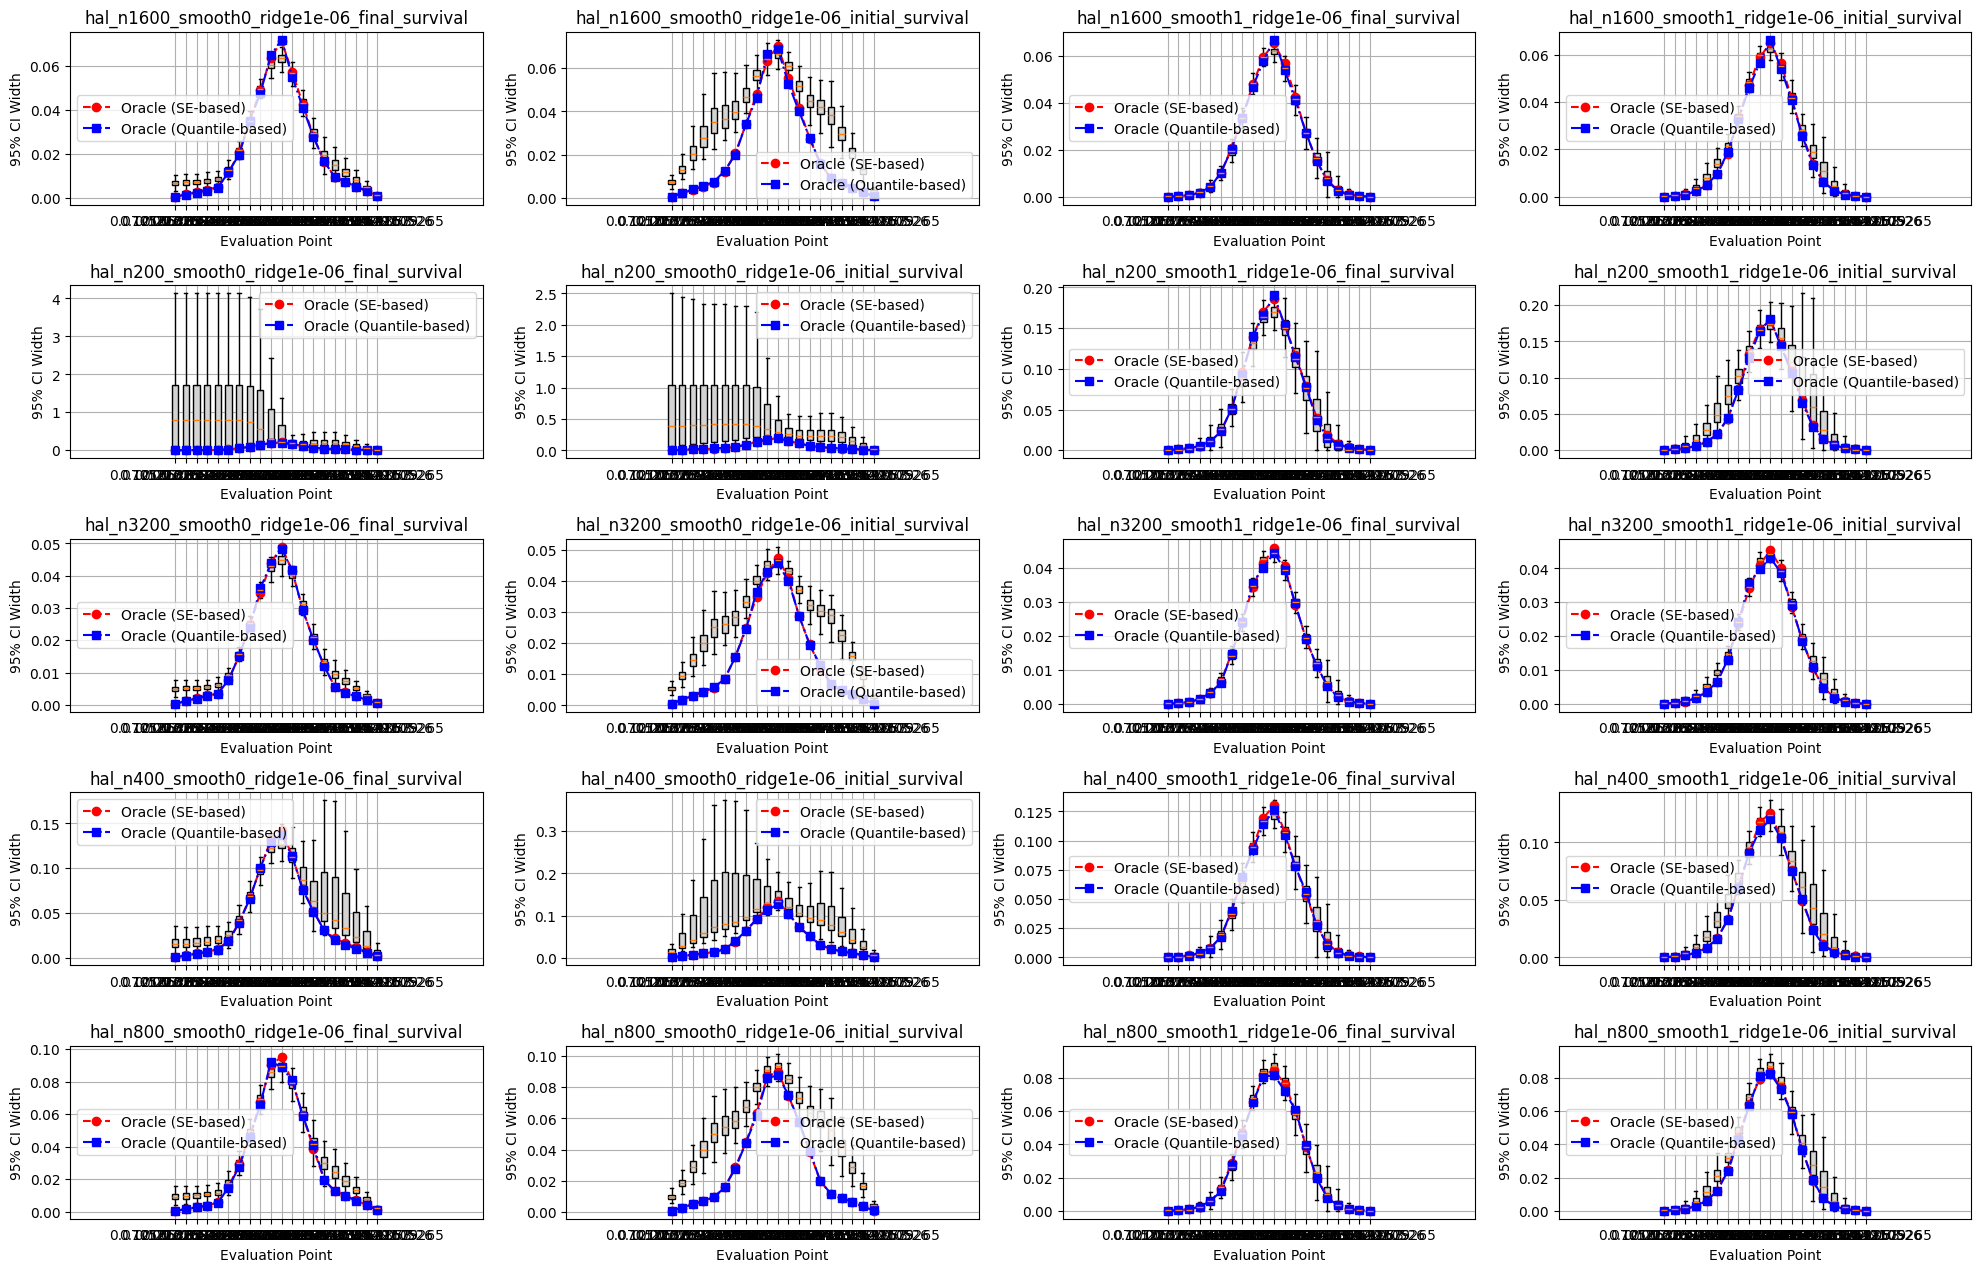

In [11]:
# Note to change the variable name form density to survival
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# We'll collect the CI width data and the two oracle estimates for each file pair.
ci_width_results = {}

for key in dataframes.keys():
    # Look for keys that end with '_density' (but not '_density_se')
    if key.endswith('_survival') and not key.endswith('_survival_se'):
        base_name = key
        se_key = base_name + '_se'
        if se_key in dataframes:
            density_df = dataframes[base_name]
            se_df = dataframes[se_key]

            # Assume the first column holds the evaluation (grid) points
            eval_points = density_df.iloc[:, 0].values

            # Prepare lists to store data for each evaluation point
            boxplot_data = []      # List of arrays: one array per evaluation point (CI widths across experiments)
            oracle_widths1 = []    # Oracle CI widths based on the sample standard deviation (SE-based)
            oracle_widths2 = []    # Oracle CI widths based on the quantile-based method

            # Loop over evaluation points (each row)
            for i in range(len(eval_points)):
                # -- From the _density_se file: Compute CI widths for each experiment
                se_values = se_df.iloc[i, 1:].astype(float).values
                ci_widths = 2 * 1.96 * se_values
                boxplot_data.append(ci_widths)

                # -- From the _density file: Get the point estimates for this evaluation point
                point_estimates = density_df.iloc[i, 1:].astype(float).values

                # Oracle Method 1: SE-based oracle
                oracle_se = np.std(point_estimates, ddof=1)
                oracle_ci_width1 = 2 * 1.96 * oracle_se
                oracle_widths1.append(oracle_ci_width1)

                # Oracle Method 2: Quantile-based oracle
                # First, compute the mean and std (psi_n and sigma_n)
                psi_n = np.mean(point_estimates)
                sigma_n = np.std(point_estimates, ddof=1)
                # Standardize the estimates
                z_vals = (point_estimates - psi_n) / sigma_n
                # Get the 2.5th and 97.5th percentiles of the standardized values
                q_lower = np.percentile(z_vals, 2.5)
                q_upper = np.percentile(z_vals, 97.5)
                # The CI width is sigma_n times the difference in quantiles
                oracle_ci_width2 = sigma_n * (q_upper - q_lower)
                oracle_widths2.append(oracle_ci_width2)

            # Save the computed results for this file pair.
            ci_width_results[base_name] = {
                'eval_points': eval_points,
                'boxplot_data': boxplot_data,
                'oracle_widths1': oracle_widths1,
                'oracle_widths2': oracle_widths2
            }

# ---
# Now plot the results in a 4x4 grid.
file_names = sorted(ci_width_results.keys())
n_files = len(file_names)
nrows, ncols = 8, 4

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 20))
axes = axes.flatten()

for idx, base_name in enumerate(file_names):
    ax = axes[idx]
    res = ci_width_results[base_name]
    eval_points = res['eval_points']
    box_data = res['boxplot_data']
    oracle1 = res['oracle_widths1']
    oracle2 = res['oracle_widths2']

    # Create the boxplot.
    # We'll use the evaluation points as the positions.
    bp = ax.boxplot(box_data, positions=eval_points, widths=0.03, patch_artist=True, showfliers=False)

    # Customize the boxplot (optional)
    for box in bp['boxes']:
        box.set(facecolor='lightgray')

    ax.set_title(base_name)
    ax.set_xlabel("Evaluation Point")
    ax.set_ylabel("95% CI Width")

    # Overlay the oracle estimates as lines.
    ax.plot(eval_points, oracle1, color='red', linestyle='--', marker='o', label='Oracle (SE-based)')
    ax.plot(eval_points, oracle2, color='blue', linestyle='-.', marker='s', label='Oracle (Quantile-based)')
    ax.legend()
    ax.grid(True)

# Remove any extra subplots if there are fewer than 16 file pairs.
for j in range(idx + 1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


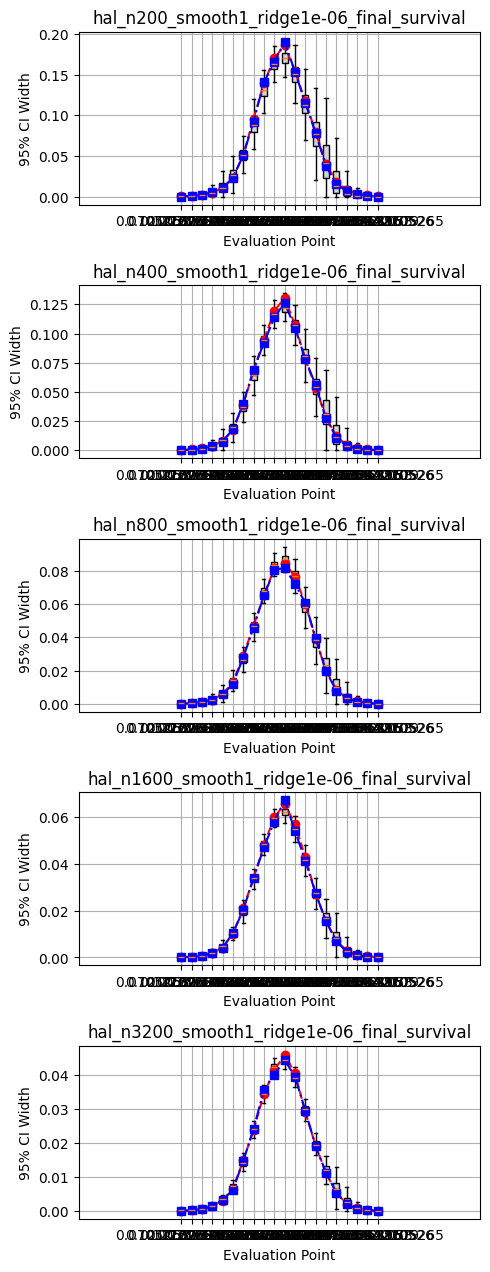

In [12]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Filter for keys that correspond to smooth order 1 and final survival results.
ci_width_results = {}

for key in dataframes.keys():
    # We only want keys that end with '_survival' (and not '_survival_se') and contain 'smooth1'
    if key.endswith('final_survival') and not key.endswith('_survival_se') and "smooth1" in key:
        base_name = key
        se_key = base_name + '_se'
        if se_key in dataframes:
            survival_df = dataframes[base_name]
            se_df = dataframes[se_key]

            # Assume the first column holds the evaluation (grid) points.
            eval_points = survival_df.iloc[:, 0].values

            boxplot_data = []      # List of arrays: one array per evaluation point (CI widths across experiments)
            oracle_widths1 = []    # Oracle CI widths based on the sample standard deviation (SE-based)
            oracle_widths2 = []    # Oracle CI widths based on the quantile-based method

            for i in range(len(eval_points)):
                se_values = se_df.iloc[i, 1:].astype(float).values
                ci_widths = 2 * 1.96 * se_values
                boxplot_data.append(ci_widths)

                point_estimates = survival_df.iloc[i, 1:].astype(float).values

                oracle_se = np.std(point_estimates, ddof=1)
                oracle_ci_width1 = 2 * 1.96 * oracle_se
                oracle_widths1.append(oracle_ci_width1)

                psi_n = np.mean(point_estimates)
                sigma_n = np.std(point_estimates, ddof=1)
                z_vals = (point_estimates - psi_n) / sigma_n
                q_lower = np.percentile(z_vals, 2.5)
                q_upper = np.percentile(z_vals, 97.5)
                oracle_ci_width2 = sigma_n * (q_upper - q_lower)
                oracle_widths2.append(oracle_ci_width2)

            ci_width_results[base_name] = {
                'eval_points': eval_points,
                'boxplot_data': boxplot_data,
                'oracle_widths1': oracle_widths1,
                'oracle_widths2': oracle_widths2
            }

# Define a helper function to extract sample size from the key.
def extract_sample_size(key):
    match = re.search(r"hal_n(\d+)_", key)
    if match:
        return int(match.group(1))
    else:
        return float('inf')

# Filter keys that are in smooth order 1 and sort them by sample size.
file_names = [k for k in ci_width_results.keys() if "smooth1" in k]
file_names = sorted(file_names, key=extract_sample_size)

# Plot the results in an 8x4 grid.
n_files = len(file_names)
nrows, ncols = 8, 1
fig, axes = plt.subplots(nrows, ncols, figsize=(5, 20))
axes = axes.flatten()

for idx, base_name in enumerate(file_names):
    ax = axes[idx]
    res = ci_width_results[base_name]
    eval_points = res['eval_points']
    box_data = res['boxplot_data']
    oracle1 = res['oracle_widths1']
    oracle2 = res['oracle_widths2']

    bp = ax.boxplot(box_data, positions=eval_points, widths=0.03, patch_artist=True, showfliers=False)
    for box in bp['boxes']:
        box.set(facecolor='lightgray')

    ax.set_title(base_name)
    ax.set_xlabel("Evaluation Point")
    ax.set_ylabel("95% CI Width")
    ax.plot(eval_points, oracle1, color='red', linestyle='--', marker='o', label='Oracle (SE-based)')
    ax.plot(eval_points, oracle2, color='blue', linestyle='-.', marker='s', label='Oracle (Quantile-based)')
    #ax.legend()
    ax.grid(True)

for j in range(idx + 1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Reading file: hal_n1600_smooth1_ridge1e-06_final_survival.csv
Reading file: hal_n1600_smooth0_ridge1e-06_final_survival.csv
Reading file: hal_n800_smooth1_ridge1e-06_final_survival.csv
Reading file: hal_n200_smooth0_ridge1e-06_final_survival.csv
Reading file: hal_n3200_smooth1_ridge1e-06_final_survival.csv
Reading file: hal_n400_smooth1_ridge1e-06_final_survival.csv
Reading file: hal_n800_smooth0_ridge1e-06_final_survival.csv
Reading file: hal_n400_smooth0_ridge1e-06_final_survival.csv
Reading file: hal_n3200_smooth0_ridge1e-06_final_survival.csv
Reading file: hal_n200_smooth1_ridge1e-06_final_survival.csv


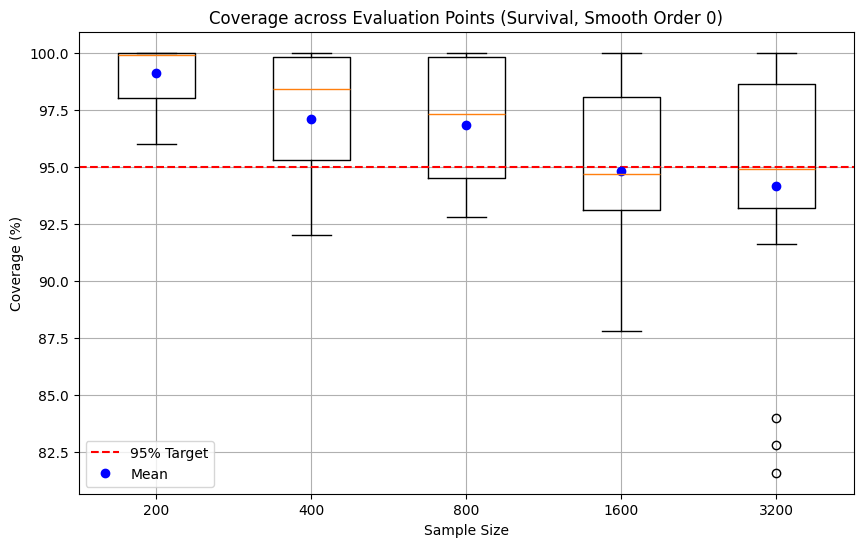

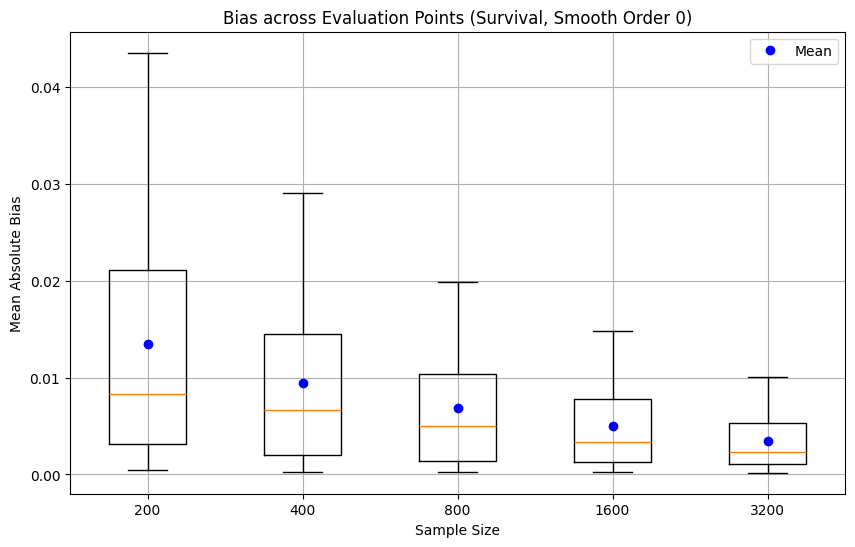

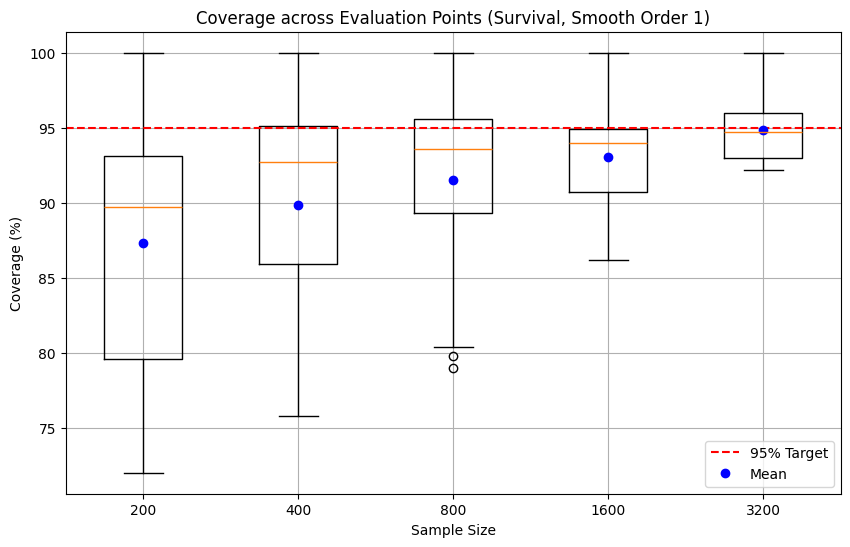

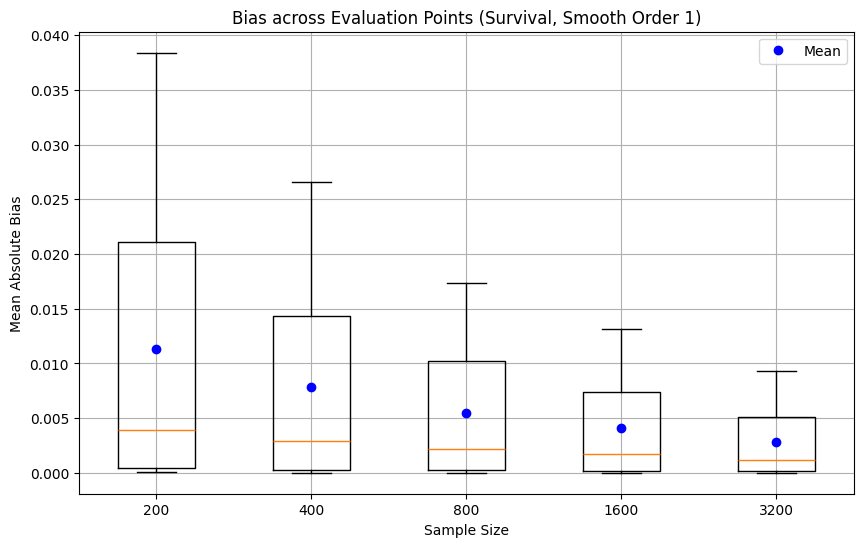

In [13]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

# Define a function to compute the true survival (using the survival function)
def compute_true_survival(grid_points, mean=0.5, std=0.1, lower=0, upper=1):
    a, b = (lower - mean) / std, (upper - mean) / std
    return truncnorm.sf(grid_points, a, b, loc=mean, scale=std)


# Get all final survival CSV files (adjust the pattern if needed)
survival_files = glob.glob(os.path.join(folder_path, "*final_survival.csv"))

# Dictionaries to store aggregated coverage and bias data per (sample size, smooth order)
coverage_data_surv = {}
bias_data_surv = {}

# Loop over each survival file
for survival_file in survival_files:
    basename = os.path.basename(survival_file)
    print("Reading file:", basename)
    # Extract sample size and smooth order from the file name.
    # Example filename: "hal_n800_smooth0_final_survival.csv"
    match = re.search(r"hal_n(\d+)_smooth(\d+)_", basename)
    if not match:
        print("No sample size or smooth order found in:", basename)
        continue
    n_samples = int(match.group(1))
    smooth_order = int(match.group(2))
    key = (n_samples, smooth_order)
    
    # Determine the corresponding standard error file name
    se_file = survival_file.replace("final_survival.csv", "final_survival_se.csv")
    if not os.path.exists(se_file):
        print(f"SE file not found for {survival_file}")
        continue

    # Read the CSV files into DataFrames
    survival_df = pd.read_csv(survival_file)
    se_df = pd.read_csv(se_file)
    
    # Assume the first column is the evaluation grid and the rest are simulation experiments
    eval_points = survival_df.iloc[:, 0].values
    true_survival = compute_true_survival(eval_points)
    
    # Lists to store the coverage (%) and bias (mean absolute difference) per evaluation point
    coverage_per_eval = []
    bias_per_eval = []
    
    # Loop over evaluation points (rows)
    for i in range(len(eval_points)):
        # Extract estimated survival values and standard errors for each replicate at evaluation point i
        est_values = survival_df.iloc[i, 1:].astype(float).values
        se_values  = se_df.iloc[i, 1:].astype(float).values
        
        # Construct the 95% confidence intervals (using 1.96*SE)
        lower_bounds = est_values - 1.96 * se_values
        upper_bounds = est_values + 1.96 * se_values
        
        # Coverage: percentage of experiments for which the true survival is inside the CI
        cov_percentage = np.mean((true_survival[i] >= lower_bounds) & (true_survival[i] <= upper_bounds)) * 100
        coverage_per_eval.append(cov_percentage)
        
        # Bias: mean absolute difference between estimated survival and true survival at this grid point
        bias_val = np.mean(np.abs(est_values - true_survival[i]))
        bias_per_eval.append(bias_val)
    
    # Store the results aggregated by (n_samples, smooth_order)
    if key in coverage_data_surv:
        coverage_data_surv[key].extend(coverage_per_eval)
        bias_data_surv[key].extend(bias_per_eval)
    else:
        coverage_data_surv[key] = coverage_per_eval
        bias_data_surv[key] = bias_per_eval

# Group the results by smooth order.
smooth_orders = sorted(set(s for (n, s) in coverage_data_surv.keys()))

for smooth in smooth_orders:
    # For the current smooth order, extract the sample sizes and their corresponding data.
    sample_sizes = sorted(n for (n, s) in coverage_data_surv.keys() if s == smooth)
    coverage_boxplot_data_surv = [coverage_data_surv[(n, smooth)] for n in sample_sizes]
    bias_boxplot_data_surv = [bias_data_surv[(n, smooth)] for n in sample_sizes]
    
    # Plot box plots for Coverage (Survival fits) for this smooth order.
    plt.figure(figsize=(10, 6))
    plt.boxplot(coverage_boxplot_data_surv)
    plt.axhline(y=95, color='red', linestyle='--', label='95% Target')
    # Compute and overlay the mean for each group.
    means_coverage_surv = [np.mean(group) for group in coverage_boxplot_data_surv]
    plt.plot(range(1, len(means_coverage_surv) + 1), means_coverage_surv,
             marker='o', color='blue', linestyle='None', label='Mean')
    plt.xticks(ticks=range(1, len(sample_sizes) + 1), labels=[str(n) for n in sample_sizes])
    plt.xlabel("Sample Size")
    plt.ylabel("Coverage (%)")
    plt.title(f"Coverage across Evaluation Points (Survival, Smooth Order {smooth})")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Plot box plots for Bias (Survival fits) for this smooth order.
    plt.figure(figsize=(10, 6))
    plt.boxplot(bias_boxplot_data_surv)
    means_bias_surv = [np.mean(group) for group in bias_boxplot_data_surv]
    plt.plot(range(1, len(means_bias_surv) + 1), means_bias_surv,
             marker='o', color='blue', linestyle='None', label='Mean')
    plt.xticks(ticks=range(1, len(sample_sizes) + 1), labels=[str(n) for n in sample_sizes])
    plt.xlabel("Sample Size")
    plt.ylabel("Mean Absolute Bias")
    plt.title(f"Bias across Evaluation Points (Survival, Smooth Order {smooth})")
    plt.legend()
    plt.grid(True)
    plt.show()


Processing: hal_n1600_smooth1_ridge1e-06_final_survival.csv
Processing: hal_n1600_smooth0_ridge1e-06_final_survival.csv
Processing: hal_n800_smooth1_ridge1e-06_final_survival.csv
Processing: hal_n200_smooth0_ridge1e-06_final_survival.csv
Processing: hal_n3200_smooth1_ridge1e-06_final_survival.csv
Processing: hal_n400_smooth1_ridge1e-06_final_survival.csv
Processing: hal_n800_smooth0_ridge1e-06_final_survival.csv
Processing: hal_n400_smooth0_ridge1e-06_final_survival.csv
Processing: hal_n3200_smooth0_ridge1e-06_final_survival.csv
Processing: hal_n200_smooth1_ridge1e-06_final_survival.csv


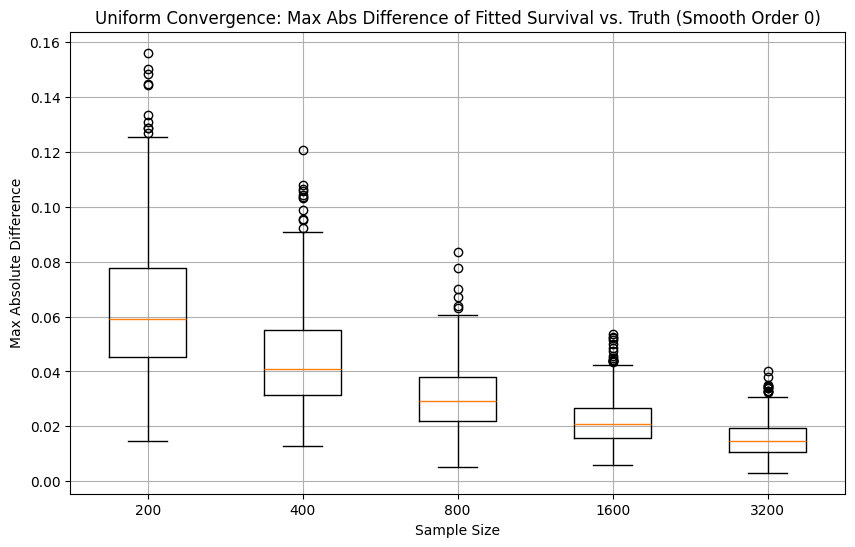

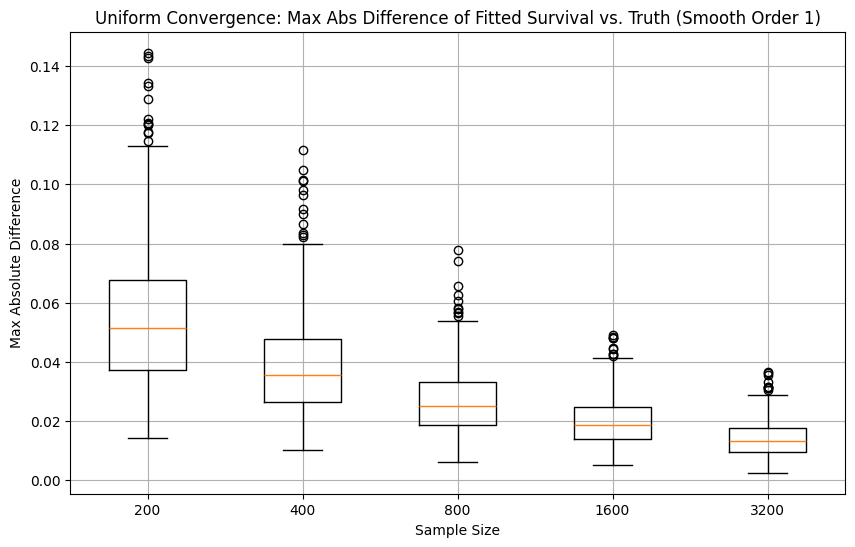

In [14]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

# Define a function to compute the true survival (using the survival function)
def compute_true_survival(grid_points, mean=0.5, std=0.1, lower=0, upper=1):
    a, b = (lower - mean) / std, (upper - mean) / std
    return truncnorm.sf(grid_points, a, b, loc=mean, scale=std)



# Get all final survival CSV files (adjust the pattern if needed)
survival_files = glob.glob(os.path.join(folder_path, "*final_survival.csv"))

# Dictionary to store the uniform convergence metric for each (sample size, smooth order).
# For each key, we store a list of maximum absolute differences (one per simulation replicate).
uniform_diff_data_surv = {}

# Loop over each survival file
for survival_file in survival_files:
    basename = os.path.basename(survival_file)
    print("Processing:", basename)
    # Extract both sample size and smooth order from the file name.
    # Example filename: "hal_n800_smooth0_final_survival.csv"
    match = re.search(r"hal_n(\d+)_smooth(\d+)_", basename)
    if not match:
        print("No sample size or smooth order found in:", basename)
        continue
    n_samples = int(match.group(1))
    smooth_order = int(match.group(2))
    key = (n_samples, smooth_order)
    
    # Read the CSV file into a DataFrame
    survival_df = pd.read_csv(survival_file)
    
    # Assume the first column is the evaluation grid and the rest are simulation experiments.
    eval_points = survival_df.iloc[:, 0].values
    true_survival = compute_true_survival(eval_points)
    
    # For each simulation replicate (each column after the first),
    # calculate the maximum absolute difference between the fitted survival and the truth.
    max_diffs = []
    for col in survival_df.columns[1:]:
        # Convert the experiment's estimated survival to float
        est_values = survival_df[col].astype(float).values
        # Compute absolute differences at each evaluation point
        abs_diff = np.abs(est_values - true_survival)
        # The uniform error is the maximum absolute difference over the grid
        max_diff = np.max(abs_diff)
        max_diffs.append(max_diff)
    
    # Aggregate the maximum differences by (sample size, smooth order)
    if key in uniform_diff_data_surv:
        uniform_diff_data_surv[key].extend(max_diffs)
    else:
        uniform_diff_data_surv[key] = max_diffs

# Group the results by smooth order.
smooth_orders = sorted(set(s for (n, s) in uniform_diff_data_surv.keys()))

for smooth in smooth_orders:
    # For the current smooth order, extract sample sizes and corresponding data.
    sample_sizes = sorted(n for (n, s) in uniform_diff_data_surv.keys() if s == smooth)
    uniform_boxplot_data_surv = [uniform_diff_data_surv[(n, smooth)] for n in sample_sizes]
    
    # Plot the box plot for uniform convergence for this smooth order.
    plt.figure(figsize=(10, 6))
    plt.boxplot(uniform_boxplot_data_surv)
    plt.xticks(ticks=range(1, len(sample_sizes) + 1), labels=[str(n) for n in sample_sizes])
    plt.xlabel("Sample Size")
    plt.ylabel("Max Absolute Difference")
    plt.title(f"Uniform Convergence: Max Abs Difference of Fitted Survival vs. Truth (Smooth Order {smooth})")
    plt.grid(True)
    plt.show()


In [15]:
# Assume summary_df contains the following columns:
# 'File', 'Wasserstein Dist.', 'Oracle1 IQR Coverage (prop.)'
# We'll compute the composite score if it hasn't been computed yet:
summary_df_survival['Composite Score'] = 50 * summary_df_survival['Oracle1 IQR Coverage (prop.)'] + 50 * summary_df_survival['Oracle2 IQR Coverage (prop.)'] - summary_df_survival['Wasserstein Dist.']

# Create a new column 'Smooth' based on the file name,
# assuming that the file name contains either 'smooth1' or 'smooth0'
summary_df_survival['Smooth'] = summary_df_survival['File'].apply(lambda x: 'smooth1' if 'smooth1' in x else 'smooth0')

# Group by the 'Smooth' column and select the top two files by composite score for each group.
best_smooth1_survival = summary_df_survival[summary_df_survival['Smooth'] == 'smooth1'].sort_values('Composite Score', ascending=False).head(2)
best_smooth0_survival = summary_df_survival[summary_df_survival['Smooth'] == 'smooth0'].sort_values('Composite Score', ascending=False).head(2)

print("Top two files in smooth1:")
print(best_smooth1_survival)
print("\nTop two files in smooth0:")
print(best_smooth0_survival)

NameError: name 'summary_df_survival' is not defined

In [16]:
!pip install lifelines
from lifelines import KaplanMeierFitter

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from scipy.stats import truncnorm, norm

# ---------------------------
# Data Generation Functions
# ---------------------------
def generate_truncated_normal(n_samples, mean=0.5, std=0.1, lower=0, upper=1):
    """Generate event times from a truncated normal distribution on [lower, upper]."""
    a, b = (lower - mean) / std, (upper - mean) / std
    return truncnorm.rvs(a, b, loc=mean, scale=std, size=n_samples)

def generate_uniform(n_samples):
    """Generate censoring times from a uniform distribution on [0,1]."""
    return np.random.uniform(0, 1, n_samples)

def convert_to_survival_data(T, C):
    """
    Given true event times T and censoring times C, create right-censored observations.
    Returns a DataFrame with columns:
      - T_tilde: observed time = min(T, C)
      - delta: event indicator (1 if event is observed, 0 if censored)
    """
    T_tilde = np.minimum(T, C)
    delta = (T <= C).astype(int)
    return pd.DataFrame({"T_tilde": T_tilde, "delta": delta})

# ---------------------------
# Parameters and Evaluation Grid
# ---------------------------
n_experiments = 200
n_samples = 1000
# Define a fixed grid of 20 evaluation points (for example, between 0.02 and 0.98)
eval_points = np.linspace(0.02, 0.98, 20)
n_eval = len(eval_points)

# True survival function for our DGP (truncated normal with mean=0.5, std=0.1, lower=0, upper=1)
a_true = (0 - 0.5) / 0.1
b_true = (1 - 0.5) / 0.1
true_survival = truncnorm.sf(eval_points, a_true, b_true, loc=0.5, scale=0.1)

# ---------------------------
# 1. Kaplan–Meier (KM) Experiments
# ---------------------------
km_surv_estimates = np.zeros((n_eval, n_experiments))
km_se_estimates   = np.zeros((n_eval, n_experiments))

for i in range(n_experiments):
    seed = 12776 + i
    np.random.seed(seed)
    T = generate_truncated_normal(n_samples)
    C = generate_uniform(n_samples)
    data = convert_to_survival_data(T, C)

    kmf = KaplanMeierFitter()
    kmf.fit(data['T_tilde'], event_observed=data['delta'])

    # Evaluate KM survival function on eval_points
    surv = kmf.predict(eval_points)
    km_surv_estimates[:, i] = surv.values

    # Approximate SE using the 95% CI from lifelines
    ci = kmf.confidence_interval_.reindex(eval_points, method='nearest')
    lower_bound = ci.iloc[:, 0]
    upper_bound = ci.iloc[:, 1]
    se_vals = (upper_bound - lower_bound) / (2 * 1.96)
    km_se_estimates[:, i] = se_vals.values

# Compute KM Coverage, Oracle Coverages, and store CI width data.
km_coverage = []             # Estimated coverage at each eval point
km_oracle_coverage = []      # Oracle_1 (SE-based) coverage
km_oracle2_coverage = []     # Oracle_2 (Quantile-based) coverage
km_boxplot_data = []         # For each eval point, array of 95% CI widths from experiments
km_oracle_widths1 = []       # Oracle CI widths (SE-based)
km_oracle_widths2 = []       # Oracle CI widths (Percentile-based)

for i in range(n_eval):
    estimates = km_surv_estimates[i, :]
    ses = km_se_estimates[i, :]
    lower_bounds = estimates - 1.96 * ses
    upper_bounds = estimates + 1.96 * ses
    # Estimated coverage using provided SE's:
    cov = np.mean((true_survival[i] >= lower_bounds) & (true_survival[i] <= upper_bounds)) * 100
    km_coverage.append(cov)

    # Boxplot widths from each experiment:
    widths = 2 * 1.96 * ses
    km_boxplot_data.append(widths)

    # Oracle_1 coverage: using oracle SE from the estimates
    mu = np.mean(estimates)
    sigma = np.std(estimates, ddof=1)
    if sigma == 0:
        cov_oracle = 100.0 if (mu - 1.96 * sigma <= true_survival[i] <= mu + 1.96 * sigma) else 0.0
    else:
        cov_oracle = (norm.cdf((mu + 1.96*sigma - true_survival[i]) / sigma) -
                      norm.cdf((mu - 1.96*sigma - true_survival[i]) / sigma)) * 100
    km_oracle_coverage.append(cov_oracle)

    # Oracle_2 coverage: quantile-based approach on the estimates
    if sigma == 0:
        cov_oracle2 = 100.0 if (mu - 1.96 * sigma <= true_survival[i] <= mu + 1.96 * sigma) else 0.0
    else:
        z_vals = (estimates - mu) / sigma
        q_lower = np.percentile(z_vals, 2.5)
        q_upper = np.percentile(z_vals, 97.5)
        lower_bound_q = mu + q_lower * sigma
        upper_bound_q = mu + q_upper * sigma
        cov_oracle2 = 100.0 if (true_survival[i] >= lower_bound_q and true_survival[i] <= upper_bound_q) else 0.0
    km_oracle2_coverage.append(cov_oracle2)

    # Oracle CI width computations
    km_oracle_widths1.append(2 * 1.96 * sigma)
    p2_5 = np.percentile(estimates, 2.5)
    p97_5 = np.percentile(estimates, 97.5)
    km_oracle_widths2.append(p97_5 - p2_5)

km_coverage = np.array(km_coverage)
km_oracle_coverage = np.array(km_oracle_coverage)
km_oracle2_coverage = np.array(km_oracle2_coverage)

# ---------------------------
# 2. HAL Survival Estimators (smooth1 and smooth0)
# ---------------------------
# These functions assume that your 'dataframes' dictionary contains the HAL estimates.
# We now compute three coverage metrics and the CI width (boxplot) data.
def compute_hal_coverage(hal_key, hal_se_key):
    hal_df = dataframes[hal_key]
    hal_se_df = dataframes[hal_se_key]
    cov_list = []
    oracle_cov_list = []   # Oracle_1 coverage (SE-based)
    oracle2_cov_list = []  # Oracle_2 coverage (Quantile-based)
    for i in range(n_eval):
        estimates = hal_df.iloc[i, 1:].astype(float).values
        ses = hal_se_df.iloc[i, 1:].astype(float).values
        lower_bounds = estimates - 1.96 * ses
        upper_bounds = estimates + 1.96 * ses
        cov = np.mean((true_survival[i] >= lower_bounds) & (true_survival[i] <= upper_bounds)) * 100
        cov_list.append(cov)

        mu = np.mean(estimates)
        sigma = np.std(estimates, ddof=1)
        if sigma == 0:
            cov_oracle = 100.0 if (mu - 1.96*sigma <= true_survival[i] <= mu + 1.96*sigma) else 0.0
        else:
            cov_oracle = (norm.cdf((mu + 1.96*sigma - true_survival[i]) / sigma) -
                          norm.cdf((mu - 1.96*sigma - true_survival[i]) / sigma)) * 100
        oracle_cov_list.append(cov_oracle)

        # Oracle_2 coverage:
        if sigma == 0:
            cov_oracle2 = 100.0 if (mu - 1.96*sigma <= true_survival[i] <= mu + 1.96*sigma) else 0.0
        else:
            z_vals = (estimates - mu) / sigma
            q_lower = np.percentile(z_vals, 2.5)
            q_upper = np.percentile(z_vals, 97.5)
            lower_bound_q = mu + q_lower * sigma
            upper_bound_q = mu + q_upper * sigma
            cov_oracle2 = 100.0 if (true_survival[i] >= lower_bound_q and true_survival[i] <= upper_bound_q) else 0.0
        oracle2_cov_list.append(cov_oracle2)
    return np.array(cov_list), np.array(oracle_cov_list), np.array(oracle2_cov_list)

def compute_hal_boxplot_metrics(hal_key, hal_se_key):
    hal_df = dataframes[hal_key]
    hal_se_df = dataframes[hal_se_key]
    box_data = []
    oracle_widths1 = []
    oracle_widths2 = []
    for i in range(n_eval):
        estimates = hal_df.iloc[i, 1:].astype(float).values
        ses = hal_se_df.iloc[i, 1:].astype(float).values
        widths = 2 * 1.96 * ses
        box_data.append(widths)
        oracle_se = np.std(estimates, ddof=1)
        oracle_widths1.append(2 * 1.96 * oracle_se)
        p2_5 = np.percentile(estimates, 2.5)
        p97_5 = np.percentile(estimates, 97.5)
        oracle_widths2.append(p97_5 - p2_5)
    return box_data, oracle_widths1, oracle_widths2

# Compute coverage for HAL smooth1 and smooth0
hal1_coverage, hal1_oracle_coverage, hal1_oracle2_coverage = compute_hal_coverage(
    'hal_n1000_smooth1_ridge0.0001_final_survival',
    'hal_n1000_smooth1_ridge0.0001_final_survival_se'
)
hal0_coverage, hal0_oracle_coverage, hal0_oracle2_coverage = compute_hal_coverage(
    'hal_n1000_smooth0_ridge0.01_final_survival',
    'hal_n1000_smooth0_ridge0.01_final_survival_se'
)

# Compute boxplot metrics for HAL smooth1 and smooth0
hal1_boxplot_data, hal1_oracle_widths1, hal1_oracle_widths2 = compute_hal_boxplot_metrics(
    'hal_n1000_smooth1_ridge0.0001_final_survival',
    'hal_n1000_smooth1_ridge0.0001_final_survival_se'
)
hal0_boxplot_data, hal0_oracle_widths1, hal0_oracle_widths2 = compute_hal_boxplot_metrics(
    'hal_n1000_smooth0_ridge0.01_final_survival',
    'hal_n1000_smooth0_ridge0.01_final_survival_se'
)

# ---------------------------
# 3. Create 1x3 Survival Plots of Coverage (using Survival Function approach)
# ---------------------------
# For a fine grid of coverage thresholds (0% to 100%), count the number of evaluation points (out of 20)
# with coverage >= threshold.
# ---------------------------
# 3. Create 1x3 Survival Plots of Coverage (using Survival Function approach)
# ---------------------------
# For a fine grid of coverage thresholds (0% to 100%), count the number of evaluation points (out of 20)
# with coverage >= threshold.
thresholds = np.linspace(0, 100, 101)

def survival_counts(coverage_array):
    return [np.sum(coverage_array >= thr) for thr in thresholds]

km_surv_counts          = survival_counts(km_coverage)
km_oracle_surv_counts   = survival_counts(km_oracle_coverage)
km_oracle2_surv_counts  = survival_counts(km_oracle2_coverage)

hal1_surv_counts         = survival_counts(hal1_coverage)
hal1_oracle_surv_counts  = survival_counts(hal1_oracle_coverage)
hal1_oracle2_surv_counts = survival_counts(hal1_oracle2_coverage)

hal0_surv_counts         = survival_counts(hal0_coverage)
hal0_oracle_surv_counts  = survival_counts(hal0_oracle_coverage)
hal0_oracle2_surv_counts = survival_counts(hal0_oracle2_coverage)

fig1, axes1 = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Panel 1: KM Survival Plot of Coverage
axes1[0].step(thresholds, km_surv_counts, where='post', label='KM Estimated', color='blue')
axes1[0].step(thresholds, km_oracle_surv_counts, where='post', label='KM Oracle (SE-based)', color='red', linestyle='--')
axes1[0].step(thresholds, km_oracle2_surv_counts, where='post', label='KM Oracle (Quantile-based)', color='green', linestyle='-.')
axes1[0].axvline(x=95, color='black', linestyle='--', linewidth=1, label='95% Threshold')
axes1[0].set_xlabel('Coverage Threshold (%)')
axes1[0].set_ylabel('Number of Eval. Points')
axes1[0].set_title('KM')
axes1[0].legend()
axes1[0].grid(True)

# Panel 2: HAL (smooth1) Survival Plot of Coverage
axes1[1].step(thresholds, hal1_surv_counts, where='post', label='HAL (smooth1) Estimated', color='blue')
axes1[1].step(thresholds, hal1_oracle_surv_counts, where='post', label='HAL (smooth1) Oracle (SE-based)', color='red', linestyle='--')
axes1[1].step(thresholds, hal1_oracle2_surv_counts, where='post', label='HAL (smooth1) Oracle (Quantile-based)', color='green', linestyle='-.')
axes1[1].axvline(x=95, color='black', linestyle='--', linewidth=1, label='95% Threshold')
axes1[1].set_xlabel('Coverage Threshold (%)')
axes1[1].set_title('HAL (smooth1)')
axes1[1].legend()
axes1[1].grid(True)

# Panel 3: HAL (smooth0) Survival Plot of Coverage
axes1[2].step(thresholds, hal0_surv_counts, where='post', label='HAL (smooth0) Estimated', color='blue')
axes1[2].step(thresholds, hal0_oracle_surv_counts, where='post', label='HAL (smooth0) Oracle (SE-based)', color='red', linestyle='--')
axes1[2].step(thresholds, hal0_oracle2_surv_counts, where='post', label='HAL (smooth0) Oracle (Quantile-based)', color='green', linestyle='-.')
axes1[2].axvline(x=95, color='black', linestyle='--', linewidth=1, label='95% Threshold')
axes1[2].set_xlabel('Coverage Threshold (%)')
axes1[2].set_title('HAL (smooth0)')
axes1[2].legend()
axes1[2].grid(True)

fig1.suptitle('Survival Plot of Coverage', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# ---------------------------
# 4. Create 1x3 Boxplots of CI Widths with Oracle Lines
# ---------------------------
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

def plot_boxplots(ax, eval_points, boxplot_data, oracle_widths1, oracle_widths2, method_name):
    bp = ax.boxplot(boxplot_data, positions=eval_points, widths=0.08, patch_artist=True, showfliers=False)
    for box in bp['boxes']:
        box.set(facecolor='lightgray')
    ax.plot(eval_points, oracle_widths1, color='red', linestyle='--', marker='o', label='Oracle (SE-based)')
    ax.plot(eval_points, oracle_widths2, color='blue', linestyle='-.', marker='s', label='Oracle (Percentile)')
    ax.set_xlabel('Evaluation Point')
    ax.set_title(method_name)
    ax.grid(True)
    ax.legend()

plot_boxplots(axes2[0], eval_points, km_boxplot_data, km_oracle_widths1, km_oracle_widths2, 'KM')
plot_boxplots(axes2[1], eval_points, hal1_boxplot_data, hal1_oracle_widths1, hal1_oracle_widths2, 'HAL (smooth1)')
plot_boxplots(axes2[2], eval_points, hal0_boxplot_data, hal0_oracle_widths1, hal0_oracle_widths2, 'HAL (smooth0)')

axes2[0].set_ylabel('95% CI Width')
fig2.suptitle('Boxplots of CI Widths with Oracle Lines', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


KeyError: 'hal_n1000_smooth1_ridge0.0001_final_survival'

IndexError: index 16 is out of bounds for axis 0 with size 16

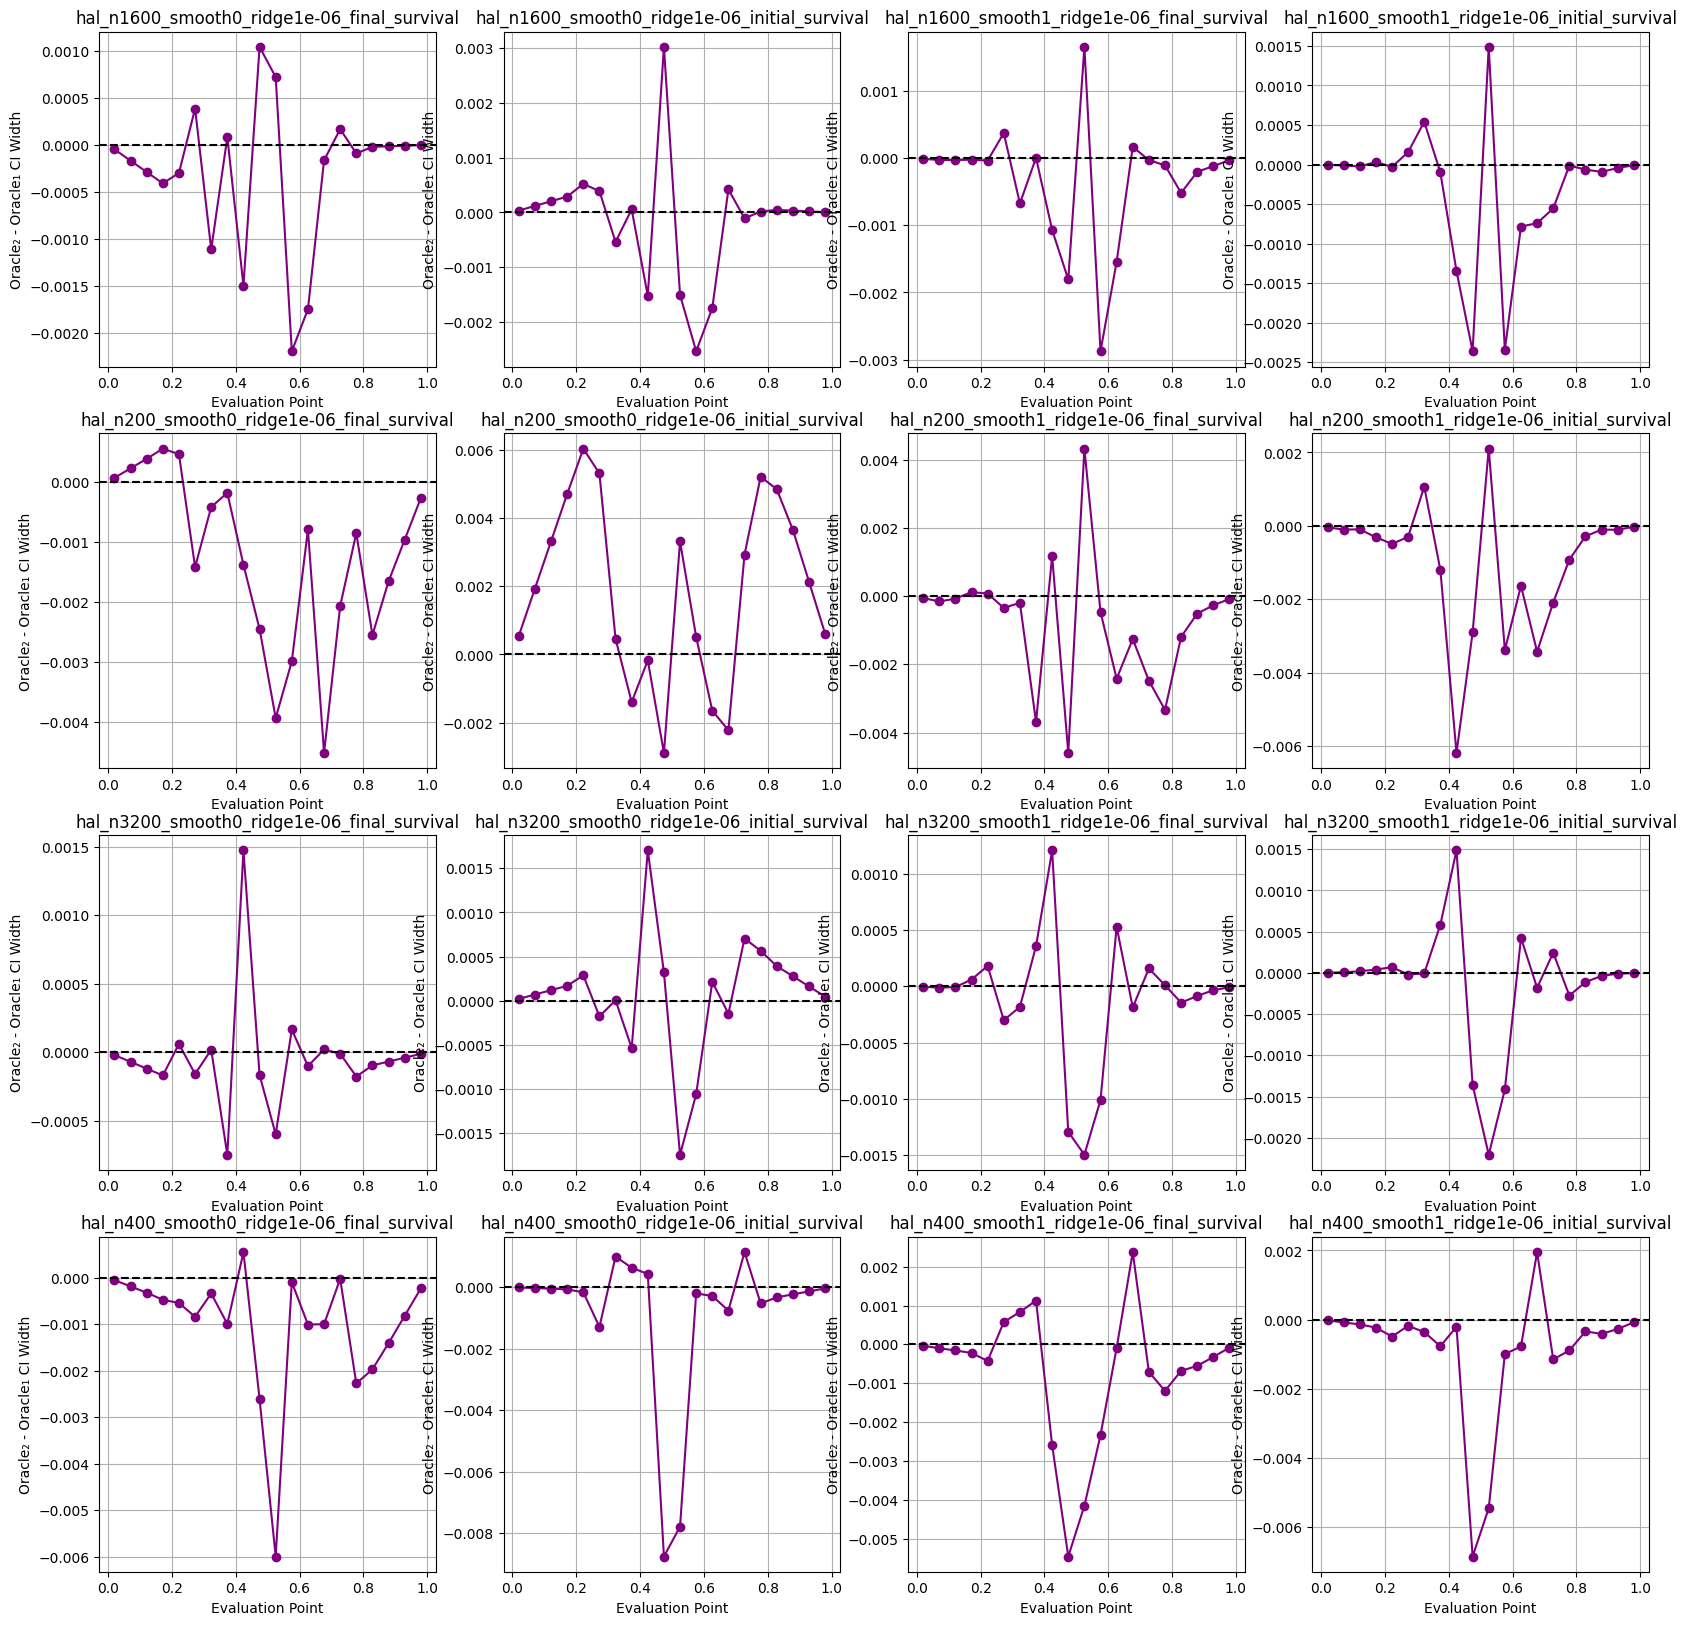

In [18]:
# Plot the difference between Oracle_2 and Oracle_1 CI widths for each file pair
file_names = sorted(ci_width_results_survival.keys())
n_files = len(file_names)
nrows, ncols = 4, 4

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 20))
axes = axes.flatten()

for idx, base_name in enumerate(file_names):
    ax = axes[idx]
    res = ci_width_results_survival[base_name]
    eval_points = res['eval_points']

    # Compute difference: Oracle_2 - Oracle_1
    oracle_diff = np.array(res['oracle_widths2']) - np.array(res['oracle_widths1'])

    # Plot the difference across evaluation points
    ax.plot(eval_points, oracle_diff, marker='o', linestyle='-', color='purple')
    ax.axhline(y=0, color='black', linestyle='--')
    ax.set_title(base_name)
    ax.set_xlabel("Evaluation Point")
    ax.set_ylabel("Oracle₂ - Oracle₁ CI Width")
    ax.grid(True)

# Remove any extra subplots if there are fewer than 16 file pairs.
for j in range(idx + 1, nrows * ncols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
